# Beyond the Scoreline

### To what extent do half-time performance indicators provide predictive information about final football match outcomes beyond the information contained in the half-time scoreline?

---

This notebook is the complete record of the study: dataset, methodology, and
all five hypotheses, each with its own experiment, results table and figures.

**The methodological rule that shapes everything below:** a model is only ever
allowed to know what was observable at the half-time whistle. Every feature is
a first-half quantity, every fold trains on earlier match-weeks and predicts
later ones, and a block of late-season matches is frozen out of the entire
development process and touched exactly once, at the end.

**Section map**

| Section | Question |
|---|---|
| 1 | Where the data comes from, and why it had to be rebuilt |
| 2 | The dataset |
| 3 | Methodology: features, models, validation, metrics, baselines |
| 4 | **H1** — is the half-time scoreline a strong predictor? |
| 5 | **H2** — is there predictive signal in performance indicators alone? |
| 6 | **H3** — does performance add anything the scoreline doesn't already say? |
| 7 | **H4** — which indicators contribute almost nothing? |
| 8 | **H5** — which indicators survive the "beyond the scoreline" test? |
| 9 | **H5 (interaction)** — does an indicator's contribution depend on the match state? |
| 10 | Algorithm comparison |
| 11 | The frozen held-out evaluation |
| 12 | Master result matrix and conclusions |
| 13 | Extension — does the answer change between league and knockout football? |


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd() / "src"))

ROOT = Path.cwd()
RESULTS = ROOT / "results"
PROCESSED = ROOT / "data" / "processed"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

NAVY, BLUE, ORANGE, GREEN, RED, GREY = "#12314f", "#2a78d6", "#eb6834", "#2e9e5b", "#c8322d", "#98a4b3"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

def show(df, n=None):
    return df.head(n) if n else df

---
## 1. Where the data comes from, and why it had to be rebuilt

The performance indicators this study needs — tackles, interceptions,
clearances, saves, pass completion, shot placement, **split at half-time** —
do not exist in any conventional match-results dataset. Football-data.co.uk
publishes full-match shot and card totals only; it has no half-time split of
any performance statistic and no possession or passing data at all.

They do exist in **StatsBomb open data** (the Hudl `open-data` archive), which
publishes every on-ball event of a match with a `period` field. Filtering to
`period == 1` gives an exact half-time cut — not an approximation.

**Why the supplied `statsbomb_half_stats.csv` could not be used directly.** It
carries all 20 indicators split by half, but it has no full-time score, no
match id, no date, no season and no home/away flag. The target variable of the
study — the final outcome — is simply not in the file, and only 235 of its
3,573 matches could be re-identified from StatsBomb metadata by team names
alone. The dataset was therefore rebuilt from the source events by
`src/ingest.py`, which keeps the identifying columns and the target.

Two deliberate differences from the supplied file, both verified against a
known match (Chelsea 2–0 Arsenal, 19 Sep 2015):

* **Saves.** The supplied file records `0` saves for every team in every match;
  its generator missed the `Goal Keeper` event type. The rebuild reads them
  correctly (Arsenal made 4 first-half saves in that match, consistent with
  Chelsea's 4 first-half shots on target).
* **Possession.** The supplied file computes possession as a team's share of
  passes attempted — which makes it an exact arithmetic function of a feature
  already in the model, and therefore useless for H4/H5. The rebuild measures
  possession as time: the summed wall-clock span of each StatsBomb possession
  chain.

Every other indicator matched the supplied file exactly on the verification
match, so the two pipelines agree on the definitions themselves.


In [2]:
team_rows = pd.read_csv(PROCESSED / "sb_halftime_2015_16.csv")
matches = pd.read_csv(PROCESSED / "matches_features.csv")

print(f"team-perspective rows : {len(team_rows):,}")
print(f"matches               : {len(matches):,}")
print(f"competitions          : {matches.competition.nunique()}")
print(f"season                : {matches.season.iloc[0]}")
print()
print(matches.groupby("competition").size().rename("matches").to_frame().to_string())

team-perspective rows : 3,034
matches               : 1,517
competitions          : 4
season                : 2015/2016

                matches
competition            
La Liga             380
Ligue 1             377
Premier League      380
Serie A             380


### Why this scope

StatsBomb's archive is deep but narrow: it covers competitions in bursts rather
than continuously. Checking every competition-season in the archive, the only
block with **complete, comparable, multi-league coverage of a single season**
is 2015/16 across the four leagues above. Everything else is a single
tournament, a single women's-league season, or a handful of cherry-picked
matches (La Liga's other seventeen "seasons" are 1–38 Messi matches each).

This has a direct methodological consequence, addressed in §3: an
expanding-window CV *by season* is impossible here, so the expanding window
runs by **match-week within the season** instead — the same "train on the past,
predict the future" guarantee at a finer granularity.

class balance (the target):
              %
FT_result      
H          44.5
D          26.5
A          29.0


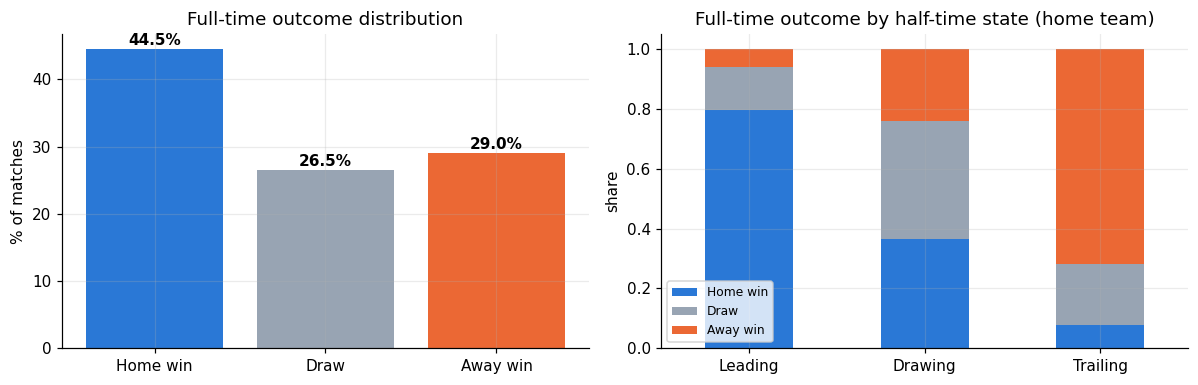


Half-time state -> full-time outcome (row-normalised):
FT_result         H     D     A
HT_state_home                  
Leading        79.6  14.4   6.0
Drawing        36.6  39.5  23.9
Trailing        7.9  20.3  71.8

matches in each half-time state:
HT_state_home
Leading     515
Drawing     648
Trailing    354


In [3]:
print("class balance (the target):")
bal = matches.FT_result.value_counts(normalize=True).reindex(["H","D","A"])
print((bal*100).round(1).rename("%").to_frame().to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(["Home win","Draw","Away win"], bal.values*100, color=[BLUE, GREY, ORANGE])
axes[0].set_ylabel("% of matches"); axes[0].set_title("Full-time outcome distribution")
for i, v in enumerate(bal.values*100):
    axes[0].text(i, v+0.6, f"{v:.1f}%", ha="center", fontweight="bold")

st = (matches.groupby("HT_state_home").FT_result.value_counts(normalize=True)
      .unstack().reindex(["Leading","Drawing","Trailing"])[["H","D","A"]])
st.plot(kind="bar", stacked=True, ax=axes[1], color=[BLUE, GREY, ORANGE], legend=False)
axes[1].set_title("Full-time outcome by half-time state (home team)")
axes[1].set_xlabel(""); axes[1].set_ylabel("share"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Home win","Draw","Away win"], fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

print("\nHalf-time state -> full-time outcome (row-normalised):")
print((st*100).round(1).to_string())
print("\nmatches in each half-time state:")
print(matches.HT_state_home.value_counts().reindex(["Leading","Drawing","Trailing"]).to_string())

**Outcome — the transition table.** This single table is the backdrop to the
whole study. It says how much of the answer the scoreline alone already
carries, before any model is fitted: read off how often a half-time lead
survives to full time, and how close to a three-way toss-up the level matches
are. Every hypothesis below is, in effect, asking whether performance
indicators can improve on what this table already knows.

---
## 3. Methodology

### 3.1 Feature architecture

The unit of analysis is the **match**, in home-vs-away perspective with
**difference features** (`X_diff = X_home − X_away`). This is deliberate: with
per-team rows a model can learn "Barcelona tends to win" rather than "the team
that was creating more chances tends to win", and the study would be measuring
club reputation instead of state of play.

| Set | Contents | Features |
|---|---|---|
| **A** | half-time scoreline only | 3 |
| **B** | performance indicators only, **no score information whatsoever** | 21 |
| **C** | A ∪ B | 24 |

`HT_state` (Leading/Drawing/Trailing) is excluded from the models — it is
deterministically derived from the goal difference, so including it would
duplicate information. It is retained only to split the analysis in §9.

A (scoreline):
    HT_home_goals, HT_away_goals, HT_goal_difference

B (performance, 21):
    possession_diff, shots_diff, shots_on_target_diff
    shots_off_target_diff, blocked_shots_diff, shots_inside_box_diff
    passes_attempted_diff, passes_completed_diff, pass_accuracy_diff
    corners_diff, free_kicks_diff, tackles_diff
    tackles_won_diff, interceptions_diff, clearances_diff
    saves_diff, fouls_diff, yellow_cards_diff
    red_cards_diff, offsides_diff, shot_accuracy_diff

C = A u B -> 24 features


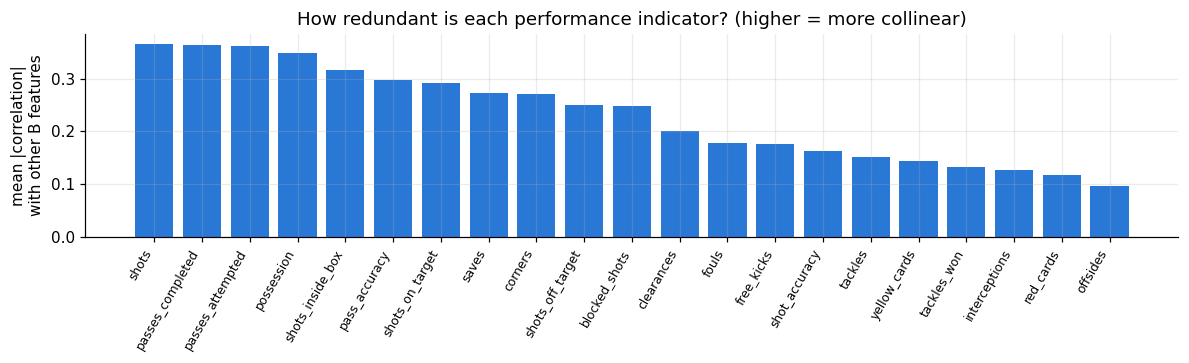

In [4]:
import features as F

print("A (scoreline):"); print("   ", ", ".join(F.A_COLS))
print("\nB (performance, 21):")
for i in range(0, len(F.B_COLS), 3):
    print("   ", ", ".join(F.B_COLS[i:i+3]))
print(f"\nC = A u B -> {len(F.C_COLS)} features")

fig, ax = plt.subplots(figsize=(11, 3.4))
corr = matches[F.B_COLS].corr().abs().mean().sort_values(ascending=False)
ax.bar(range(len(corr)), corr.values, color=BLUE)
ax.set_xticks(range(len(corr))); ax.set_xticklabels([c.replace("_diff","") for c in corr.index],
                                                    rotation=60, ha="right", fontsize=8)
ax.set_ylabel("mean |correlation|\nwith other B features")
ax.set_title("How redundant is each performance indicator? (higher = more collinear)")
plt.tight_layout(); plt.show()

**Outcome.** The passing and possession indicators are the most collinear
block — possession, passes attempted, passes completed and pass accuracy all
measure closely related things. This matters for reading H4 and H5 later: when
one member of a collinear block is removed, the others can absorb its role, so
a small ablation delta does **not** by itself prove the underlying quantity is
irrelevant. §7 returns to this directly.

### 3.2 Validation — time-aware, expanding window

Football is temporal, so randomly mixing early and late match-weeks would let a
model train on the future. Instead the window **expands**: each fold trains on
every match-week before its test block and predicts the next two.

```
fold 0   train weeks  1-10   ->  test weeks 11-12
fold 1   train weeks  1-12   ->  test weeks 13-14
fold 2   train weeks  1-14   ->  test weeks 15-16
...                                     up to week 32
```

**Hyperparameters** are chosen by an inner stratified CV *inside each training
window* (nested CV), so no fold's test block ever influences the settings used
to predict it.

**Match-weeks 33+ are frozen.** They were not looked at during feature
engineering, model selection or hypothesis development, and are evaluated
exactly once, in §11.

development block : 1,278 matches (weeks < 33)
frozen holdout    : 239 matches (weeks 33+)
folds             : 11

 fold train weeks  n train test weeks  n test
    0        1-10      400      11-12      80
    1        1-12      480      13-14      79
    2        1-14      559      15-16      80
    3        1-16      639      17-18      80
    4        1-18      719      19-20      80
    5        1-20      799      21-22      80
    6        1-22      879      23-24      79
    7        1-24      958      25-26      80
    8        1-26     1038      27-28      80
    9        1-28     1118      29-30      80
   10        1-30     1198      31-32      80


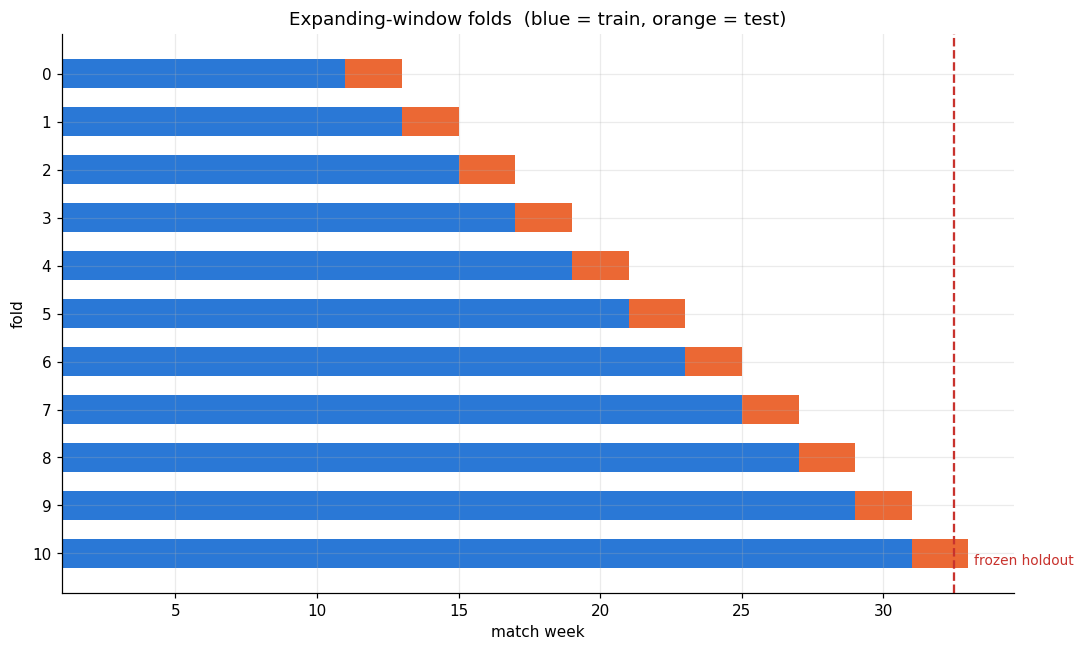

In [5]:
from protocol import expanding_window_folds, split_development_holdout, HOLDOUT_FROM_WEEK

dev, holdout = split_development_holdout(matches)
folds = expanding_window_folds(dev)
print(f"development block : {len(dev):,} matches (weeks < {HOLDOUT_FROM_WEEK})")
print(f"frozen holdout    : {len(holdout):,} matches (weeks {HOLDOUT_FROM_WEEK}+)")
print(f"folds             : {len(folds)}\n")
fold_tbl = pd.DataFrame([{"fold": f.index, "train weeks": f"{f.train_weeks[0]}-{f.train_weeks[1]}",
                          "n train": len(f.train_idx),
                          "test weeks": f"{f.test_weeks[0]}-{f.test_weeks[1]}",
                          "n test": len(f.test_idx)} for f in folds])
print(fold_tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 0.42*len(folds)+1.4))
for f in folds:
    ax.barh(f.index, f.train_weeks[1]-f.train_weeks[0]+1, left=f.train_weeks[0], color=BLUE, height=0.6)
    ax.barh(f.index, f.test_weeks[1]-f.test_weeks[0]+1, left=f.test_weeks[0], color=ORANGE, height=0.6)
ax.axvline(HOLDOUT_FROM_WEEK-0.5, color=RED, ls="--", lw=1.5)
ax.text(HOLDOUT_FROM_WEEK+0.2, len(folds)-1, "frozen holdout", color=RED, fontsize=9, va="top")
ax.set_yticks([f.index for f in folds]); ax.set_ylabel("fold"); ax.set_xlabel("match week")
ax.set_title("Expanding-window folds  (blue = train, orange = test)")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

### 3.3 Metrics and baselines

Every model records the full suite: **accuracy, macro precision/recall/F1,
weighted F1, per-class precision/recall/F1, log loss, macro ROC-AUC** and the
**multiclass Brier score**.

Macro F1 is the headline metric throughout, because roughly a quarter of
matches are draws and accuracy can be inflated by a model that simply never
predicts one.

Three baselines, from trivial upward:

| Baseline | What it does |
|---|---|
| `majority_class` | always predicts the most common training outcome (the required minimum) |
| `class_frequency` | predicts the historical outcome distribution (a probabilistic prior) |
| `halftime_leader_rule` | whoever leads at half-time wins; level → draw. No learning at all |

The third is the one that matters. It is the honest bar for this study: if a
trained model cannot beat a rule a spectator could state out loud, the machine
learning is not earning its place.

---
## 4. H1 — Is the half-time scoreline a strong predictor?

> **Hypothesis.** The half-time scoreline is a strong predictor of the final
> match outcome.

**Experiment.** Model A (three scoreline features) through all six algorithms
under the expanding-window CV, against the baselines.

The question is *not* "did Random Forest score highly once". It is whether
scoreline-only prediction is **consistently, substantially** better than the
naïve baseline, across algorithms and across temporal folds.

In [6]:
res = pd.read_csv(RESULTS / "results_folds.csv")
summ = pd.read_csv(RESULTS / "results_summary.csv")
base = pd.read_csv(RESULTS / "baselines_folds.csv")

def table(set_name):
    t = (res[res.feature_set == set_name].groupby("algorithm")
         .agg(accuracy=("accuracy","mean"), macro_precision=("macro_precision","mean"),
              macro_recall=("macro_recall","mean"), macro_f1=("macro_f1","mean"),
              macro_f1_sd=("macro_f1","std"), weighted_f1=("weighted_f1","mean"),
              log_loss=("log_loss","mean"), roc_auc=("roc_auc_macro","mean"),
              brier=("brier","mean"))
         .sort_values("macro_f1", ascending=False).round(4))
    return t

A = table("A")
print("MODEL A -- half-time scoreline only, mean over folds\n")
print(A.to_string())

bsum = base.groupby("baseline").agg(accuracy=("accuracy","mean"), macro_f1=("macro_f1","mean"),
                                    macro_f1_sd=("macro_f1","std")).round(4)
print("\nBASELINES\n"); print(bsum.to_string())

MODEL A -- half-time scoreline only, mean over folds

                    accuracy  macro_precision  macro_recall  macro_f1  macro_f1_sd  weighted_f1  log_loss  roc_auc   brier
algorithm                                                                                                                 
NaiveBayes            0.6105           0.6410        0.6117    0.6073       0.0476       0.6234    0.9186   0.7751  0.5039
DecisionTree          0.6071           0.6319        0.5990    0.5894       0.0550       0.6074    0.9867   0.7710  0.4937
kNN                   0.5910           0.5858        0.5819    0.5639       0.0907       0.5886    0.9763   0.7594  0.5083
SVM                   0.5970           0.6022        0.5694    0.5548       0.0743       0.5786    0.8895   0.7315  0.5240
RandomForest          0.5946           0.5971        0.5667    0.5519       0.0738       0.5760    0.9254   0.7688  0.4958
LogisticRegression    0.6060           0.5969        0.5529    0.5374       0.0623   

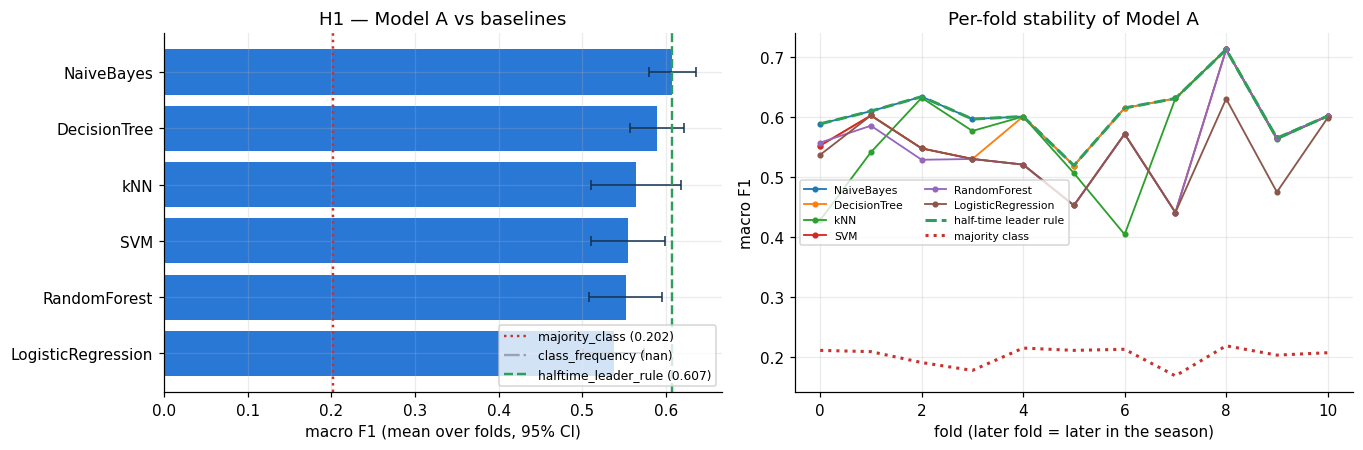

In [7]:
# 95% CI of the mean over folds, per algorithm
n = res.fold.nunique()
ci = 1.96 * A.macro_f1_sd / np.sqrt(n)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
ax.barh(A.index[::-1], A.macro_f1[::-1], xerr=ci[::-1], color=BLUE,
        error_kw=dict(ecolor=NAVY, capsize=3, lw=1))
for name, colour, ls in [("majority_class", RED, ":"), ("class_frequency", GREY, "-."),
                         ("halftime_leader_rule", GREEN, "--")]:
    v = bsum.loc[name, "macro_f1"]
    ax.axvline(v, color=colour, ls=ls, lw=1.6, label=f"{name} ({v:.3f})")
ax.set_xlabel("macro F1 (mean over folds, 95% CI)"); ax.set_title("H1 — Model A vs baselines")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
for algo in A.index:
    d = res[(res.feature_set=="A") & (res.algorithm==algo)].sort_values("fold")
    ax.plot(d.fold, d.macro_f1, marker="o", ms=3, lw=1.2, label=algo)
rule = base[base.baseline=="halftime_leader_rule"].sort_values("fold")
ax.plot(rule.fold, rule.macro_f1, color=GREEN, ls="--", lw=2, label="half-time leader rule")
maj = base[base.baseline=="majority_class"].sort_values("fold")
ax.plot(maj.fold, maj.macro_f1, color=RED, ls=":", lw=2, label="majority class")
ax.set_xlabel("fold (later fold = later in the season)"); ax.set_ylabel("macro F1")
ax.set_title("Per-fold stability of Model A"); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

In [8]:
best_a = A.macro_f1.idxmax(); best_a_f1 = A.macro_f1.max()
maj_f1 = bsum.loc["majority_class","macro_f1"]; rule_f1 = bsum.loc["halftime_leader_rule","macro_f1"]
n_beat_maj = int((A.macro_f1 > maj_f1).sum()); n_beat_rule = int((A.macro_f1 > rule_f1).sum())

print("H1 ------------------------------------------------------------------")
print(f"best Model A algorithm      : {best_a}  (macro F1 {best_a_f1:.4f}, "
      f"accuracy {A.loc[best_a,'accuracy']:.4f})")
print(f"majority-class baseline     : {maj_f1:.4f}   -> Model A beats it by "
      f"{best_a_f1-maj_f1:+.4f}")
print(f"half-time leader rule       : {rule_f1:.4f}   -> Model A beats it by "
      f"{best_a_f1-rule_f1:+.4f}")
print(f"algorithms beating majority : {n_beat_maj}/6")
print(f"algorithms beating the rule : {n_beat_rule}/6")
print(f"spread across algorithms    : {A.macro_f1.min():.4f} - {A.macro_f1.max():.4f}")
print()
if n_beat_maj == 6 and best_a_f1 - maj_f1 > 0.10:
    print("VERDICT: H1 SUPPORTED -- every algorithm beats the trivial baseline by a")
    print("wide margin, so the effect is a property of the scoreline, not of one model.")
elif n_beat_maj >= 4:
    print("VERDICT: H1 PARTIALLY SUPPORTED -- most but not all algorithms clear the")
    print("baseline; the margin is real but not uniform.")
else:
    print("VERDICT: H1 NOT SUPPORTED on this data.")
print()
print("Note the second comparison separately: beating the majority baseline shows the")
print("scoreline carries signal; beating the half-time-leader RULE shows the learning")
print("adds something beyond simply reading the scoreline off the board.")

H1 ------------------------------------------------------------------
best Model A algorithm      : NaiveBayes  (macro F1 0.6073, accuracy 0.6105)
majority-class baseline     : 0.2020   -> Model A beats it by +0.4053
half-time leader rule       : 0.6073   -> Model A beats it by +0.0000
algorithms beating majority : 6/6
algorithms beating the rule : 0/6
spread across algorithms    : 0.5374 - 0.6073

VERDICT: H1 SUPPORTED -- every algorithm beats the trivial baseline by a
wide margin, so the effect is a property of the scoreline, not of one model.

Note the second comparison separately: beating the majority baseline shows the
scoreline carries signal; beating the half-time-leader RULE shows the learning
adds something beyond simply reading the scoreline off the board.


---
## 5. H2 — Is there predictive signal in performance indicators alone?

> **Hypothesis.** Half-time performance indicators alone can predict match
> outcomes with reasonable accuracy.

**Experiment.** Model B — the 21 performance difference features, with **all
score information removed** — through the same six algorithms, the same folds,
the same metrics.

The question here is deliberately *not* "does B beat A". It is whether
performance-only prediction contains meaningful signal at all, i.e. whether it
clears the baseline.

MODEL B -- performance indicators only, no score, mean over folds

                    accuracy  macro_precision  macro_recall  macro_f1  macro_f1_sd  weighted_f1  log_loss  roc_auc   brier
algorithm                                                                                                                 
LogisticRegression    0.5821           0.5305        0.5428    0.5219       0.0552       0.5564    0.8770   0.7535  0.5151
SVM                   0.5559           0.5309        0.5240    0.5095       0.0421       0.5396    0.9331   0.7068  0.5530
NaiveBayes            0.4887           0.4812        0.4760    0.4714       0.0700       0.4927    1.4897   0.6644  0.7079
RandomForest          0.5273           0.4674        0.4774    0.4469       0.0446       0.4842    0.9844   0.6741  0.5838
DecisionTree          0.4806           0.4626        0.4531    0.4377       0.0780       0.4661    5.2879   0.6330  0.7244
kNN                   0.4544           0.4279        0.4289    0.4165   

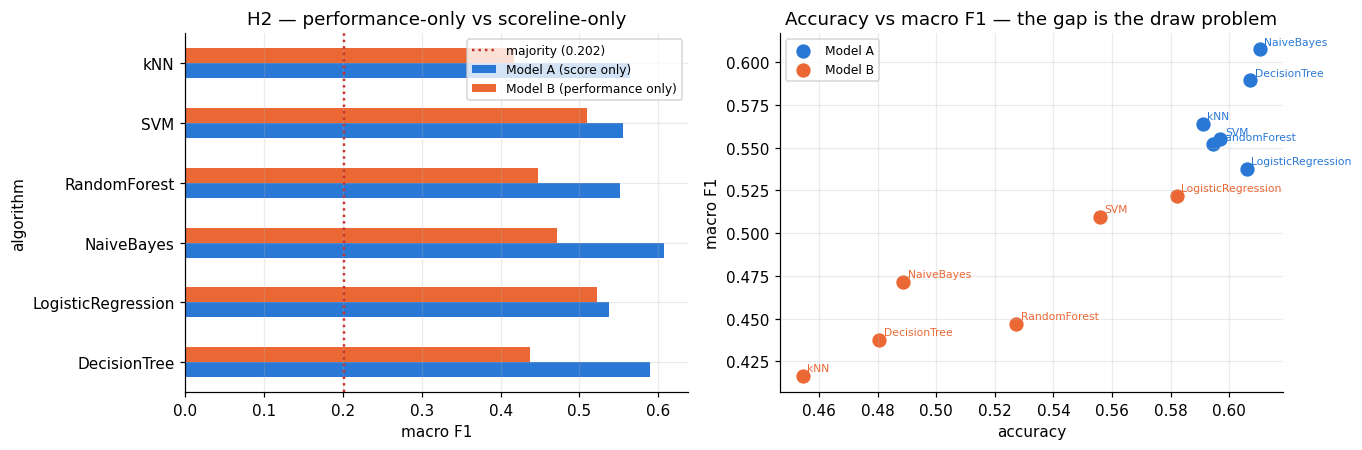

In [9]:
B = table("B")
print("MODEL B -- performance indicators only, no score, mean over folds\n")
print(B.to_string())

comp = pd.DataFrame({"Model A (score only)": A.macro_f1, "Model B (performance only)": B.macro_f1})
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
comp.plot(kind="barh", ax=axes[0], color=[BLUE, ORANGE])
axes[0].axvline(maj_f1, color=RED, ls=":", lw=1.6, label=f"majority ({maj_f1:.3f})")
axes[0].set_xlabel("macro F1"); axes[0].set_title("H2 — performance-only vs scoreline-only")
axes[0].legend(fontsize=8)

axes[1].scatter(A.accuracy, A.macro_f1, s=70, color=BLUE, label="Model A")
axes[1].scatter(B.accuracy, B.macro_f1, s=70, color=ORANGE, label="Model B")
for df_, c in ((A, BLUE), (B, ORANGE)):
    for algo in df_.index:
        axes[1].annotate(algo, (df_.loc[algo,"accuracy"], df_.loc[algo,"macro_f1"]),
                         fontsize=7, xytext=(3,3), textcoords="offset points", color=c)
axes[1].set_xlabel("accuracy"); axes[1].set_ylabel("macro F1")
axes[1].set_title("Accuracy vs macro F1 — the gap is the draw problem"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
best_b = B.macro_f1.idxmax(); best_b_f1 = B.macro_f1.max()
n_b_beat_maj = int((B.macro_f1 > maj_f1).sum())

print("H2 ------------------------------------------------------------------")
print(f"best Model B algorithm : {best_b}  (macro F1 {best_b_f1:.4f}, "
      f"accuracy {B.loc[best_b,'accuracy']:.4f})")
print(f"vs majority baseline   : {best_b_f1-maj_f1:+.4f}")
print(f"vs best Model A        : {best_b_f1-best_a_f1:+.4f}")
print(f"algorithms beating majority: {n_b_beat_maj}/6")
print()
if n_b_beat_maj >= 5 and best_b_f1 - maj_f1 > 0.05:
    print("VERDICT: H2 SUPPORTED -- performance indicators alone carry real predictive")
    print("signal, clearly above the trivial baseline.")
elif n_b_beat_maj >= 3:
    print("VERDICT: H2 PARTIALLY SUPPORTED -- some signal, but it is not robust across")
    print("algorithms.")
else:
    print("VERDICT: H2 NOT SUPPORTED -- performance indicators alone do not clear the baseline.")
print()
print(f"Separately, and this is the interesting number: Model B trails Model A by "
      f"{best_a_f1-best_b_f1:.4f} macro F1")
print("despite having 21 features to Model A's 3. Twenty-one measurements of how the")
print("half was played carry less than three numbers describing what it was worth.")

H2 ------------------------------------------------------------------
best Model B algorithm : LogisticRegression  (macro F1 0.5219, accuracy 0.5821)
vs majority baseline   : +0.3199
vs best Model A        : -0.0854
algorithms beating majority: 6/6

VERDICT: H2 SUPPORTED -- performance indicators alone carry real predictive
signal, clearly above the trivial baseline.

Separately, and this is the interesting number: Model B trails Model A by 0.0854 macro F1
despite having 21 features to Model A's 3. Twenty-one measurements of how the
half was played carry less than three numbers describing what it was worth.


---
## 6. H3 — Does performance add anything beyond the scoreline?

> **Hypothesis.** Combining half-time score and performance indicators yields
> significantly better predictions than using the scoreline alone.

This is the central hypothesis, and the one where a p-value genuinely belongs.

**Why McNemar's test.** Models A and C predict the *same matches*, so their
errors are **paired**. McNemar's test looks only at the discordant matches —
those where exactly one of the two models was right — and asks whether the
split between them is more lopsided than chance. Matches both models get right,
or both get wrong, carry no information about which model is better and are
correctly ignored.

Reporting the p-value alone is not enough: the size of the improvement is
reported alongside it throughout.

In [11]:
C = table("C")
print("MODEL C -- scoreline + performance, mean over folds\n")
print(C.to_string())

delta = pd.DataFrame({
    "A_macro_f1": A.macro_f1, "C_macro_f1": C.macro_f1,
    "delta_macro_f1": C.macro_f1 - A.macro_f1,
    "A_accuracy": A.accuracy, "C_accuracy": C.accuracy,
    "delta_accuracy": C.accuracy - A.accuracy,
    "A_log_loss": A.log_loss, "C_log_loss": C.log_loss,
    "delta_log_loss": A.log_loss - C.log_loss,   # positive = C better
}).round(4)
print("\nH3 -- per-algorithm deltas (positive = C better on all three)\n")
print(delta.to_string())

MODEL C -- scoreline + performance, mean over folds

                    accuracy  macro_precision  macro_recall  macro_f1  macro_f1_sd  weighted_f1  log_loss  roc_auc   brier
algorithm                                                                                                                 
NaiveBayes            0.5979           0.6043        0.5892    0.5863       0.0463       0.6071    1.3454   0.7661  0.6078
DecisionTree          0.6151           0.5840        0.5896    0.5710       0.0839       0.6002    1.2836   0.7672  0.5100
RandomForest          0.6015           0.5739        0.5684    0.5595       0.0529       0.5879    0.8617   0.7631  0.5044
SVM                   0.5980           0.5747        0.5634    0.5562       0.0311       0.5847    0.8811   0.7465  0.5196
LogisticRegression    0.5992           0.5443        0.5605    0.5363       0.0617       0.5700    0.8287   0.7777  0.4903
kNN                   0.5706           0.5465        0.5308    0.5202       0.0618    

H3 -- McNemar's test, Model C vs Model A (pooled over all CV test blocks)

         algorithm  accuracy_A  accuracy_C  delta_accuracy  only_A_correct  only_C_correct  discordant                              test  p_value
LogisticRegression      0.6059      0.5991         -0.0068              67              61         128 chi-square (continuity-corrected)   0.6585
        NaiveBayes      0.6105      0.5979         -0.0125             115             104         219 chi-square (continuity-corrected)   0.4992
      DecisionTree      0.6071      0.6150          0.0080              61              68         129 chi-square (continuity-corrected)   0.5973
      RandomForest      0.5945      0.6014          0.0068              70              76         146 chi-square (continuity-corrected)   0.6790
               SVM      0.5968      0.5979          0.0011              79              80         159 chi-square (continuity-corrected)   1.0000
               kNN      0.5911      0.5706       

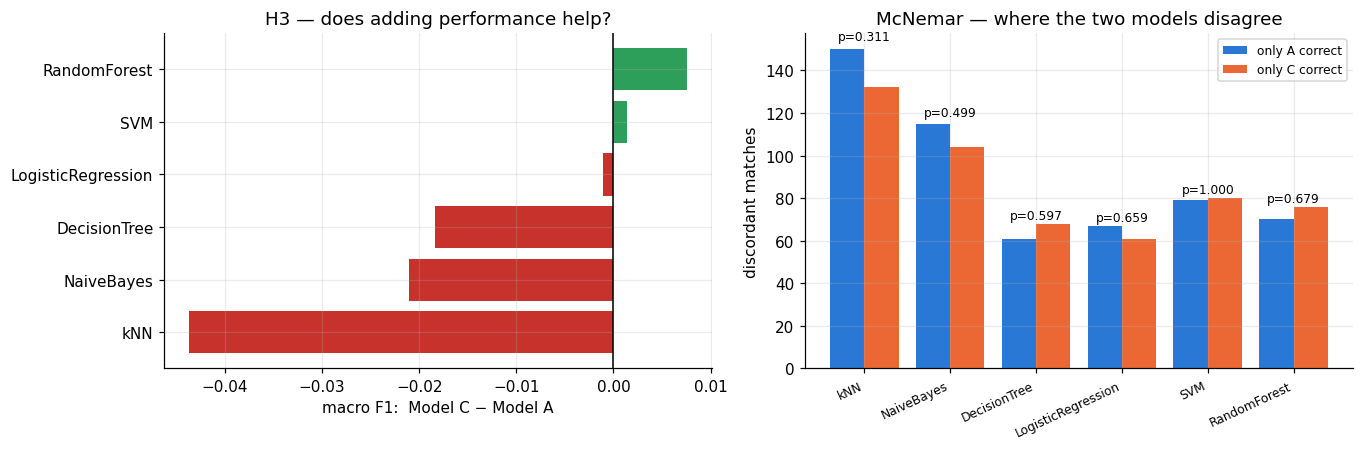

In [12]:
mc = pd.read_csv(RESULTS / "h3_mcnemar.csv")
print("H3 -- McNemar's test, Model C vs Model A (pooled over all CV test blocks)\n")
print(mc[["algorithm","accuracy_A","accuracy_C","delta_accuracy","only_A_correct",
          "only_C_correct","discordant","test","p_value"]].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
d = delta.delta_macro_f1.sort_values()
ax.barh(d.index, d.values, color=[GREEN if v > 0 else RED for v in d.values])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("macro F1:  Model C − Model A"); ax.set_title("H3 — does adding performance help?")

ax = axes[1]
m = mc.set_index("algorithm").loc[d.index]
x = np.arange(len(m))
ax.bar(x-0.2, m.only_A_correct, 0.4, color=BLUE, label="only A correct")
ax.bar(x+0.2, m.only_C_correct, 0.4, color=ORANGE, label="only C correct")
for i, (algo, r) in enumerate(m.iterrows()):
    ax.text(i, max(r.only_A_correct, r.only_C_correct)*1.03,
            f"p={r.p_value:.3f}" + ("*" if r.p_value < 0.05 else ""),
            ha="center", fontsize=8, fontweight="bold" if r.p_value < 0.05 else "normal")
ax.set_xticks(x); ax.set_xticklabels(m.index, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("discordant matches"); ax.set_title("McNemar — where the two models disagree")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [13]:
n_sig = int((mc.p_value < 0.05).sum())
n_sig_favour_c = int(((mc.p_value < 0.05) & (mc.delta_accuracy > 0)).sum())
n_sig_favour_a = int(((mc.p_value < 0.05) & (mc.delta_accuracy < 0)).sum())
n_pos = int((delta.delta_macro_f1 > 0).sum())

print("H3 ------------------------------------------------------------------")
print(f"algorithms where C beats A on macro F1 : {n_pos}/6")
print(f"mean delta macro F1                    : {delta.delta_macro_f1.mean():+.4f}")
print(f"mean delta accuracy                    : {delta.delta_accuracy.mean():+.4f}")
print(f"mean delta log loss (positive = better): {delta.delta_log_loss.mean():+.4f}")
print(f"McNemar significant (p<0.05)           : {n_sig}/6  "
      f"({n_sig_favour_c} favouring C, {n_sig_favour_a} favouring A)")
print()
if n_sig_favour_c >= 4 and n_pos >= 4:
    print("VERDICT: H3 SUPPORTED -- the combined model is significantly better than the")
    print("scoreline alone across most algorithms, and the improvement is not trivial.")
elif n_sig_favour_c >= 2:
    print("VERDICT: H3 WEAKLY SUPPORTED -- significant for some algorithms only. An effect")
    print("that appears in a minority of model families is a property of those models as")
    print("much as of the data.")
else:
    print("VERDICT: H3 NOT SUPPORTED -- adding performance indicators to the scoreline does")
    print("not produce a statistically significant improvement. Note this is a finding, not")
    print("a failure: it is the direct answer to the question the project's title asks.")

H3 ------------------------------------------------------------------
algorithms where C beats A on macro F1 : 2/6
mean delta macro F1                    : -0.0125
mean delta accuracy                    : -0.0040
mean delta log loss (positive = better): -0.2198
McNemar significant (p<0.05)           : 0/6  (0 favouring C, 0 favouring A)

VERDICT: H3 NOT SUPPORTED -- adding performance indicators to the scoreline does
not produce a statistically significant improvement. Note this is a finding, not
a failure: it is the direct answer to the question the project's title asks.


---
## 7. H4 — Which indicators contribute almost nothing?

> **Hypothesis.** Some widely cited football indicators contribute little
> additional predictive value once the half-time score is known.

The question changes here from "which model wins" to "which features matter".
Two independent measures are used, because either alone can mislead.

**1. Permutation importance.** Shuffle one feature across matches, leaving
everything else intact, and measure the drop:
$$PI_j = \text{Score}_{\text{original}} - \text{Score}_{\text{permuted},j}$$
This measures how much a *fitted* model relies on the feature.

**2. Leave-one-feature-out ablation.** Retrain without the feature entirely:
$$\Delta_j = \text{Performance}_{\text{full}} - \text{Performance}_{\text{without }j}$$
This measures whether the *other* features can compensate for its absence.

The two answer different questions and can legitimately disagree — a feature a
model leans on heavily may still be replaceable if a correlated feature can
take over. Both are computed on every fold, so stability comes for free.

PERMUTATION IMPORTANCE on Model C -- mean over folds

              feature  mean_importance  sd_importance  folds_positive  n_folds
   HT_goal_difference           0.0617         0.0359              11       11
        HT_away_goals           0.0448         0.0374              10       11
        HT_home_goals           0.0383         0.0173              11       11
   shot_accuracy_diff           0.0137         0.0176               9       11
 shots_on_target_diff           0.0122         0.0174               9       11
shots_inside_box_diff           0.0098         0.0227               8       11
      clearances_diff           0.0078         0.0137               8       11
           shots_diff           0.0059         0.0173               8       11
         corners_diff           0.0039         0.0207               5       11
    yellow_cards_diff           0.0033         0.0100               6       11
   pass_accuracy_diff           0.0032         0.0157               5       1

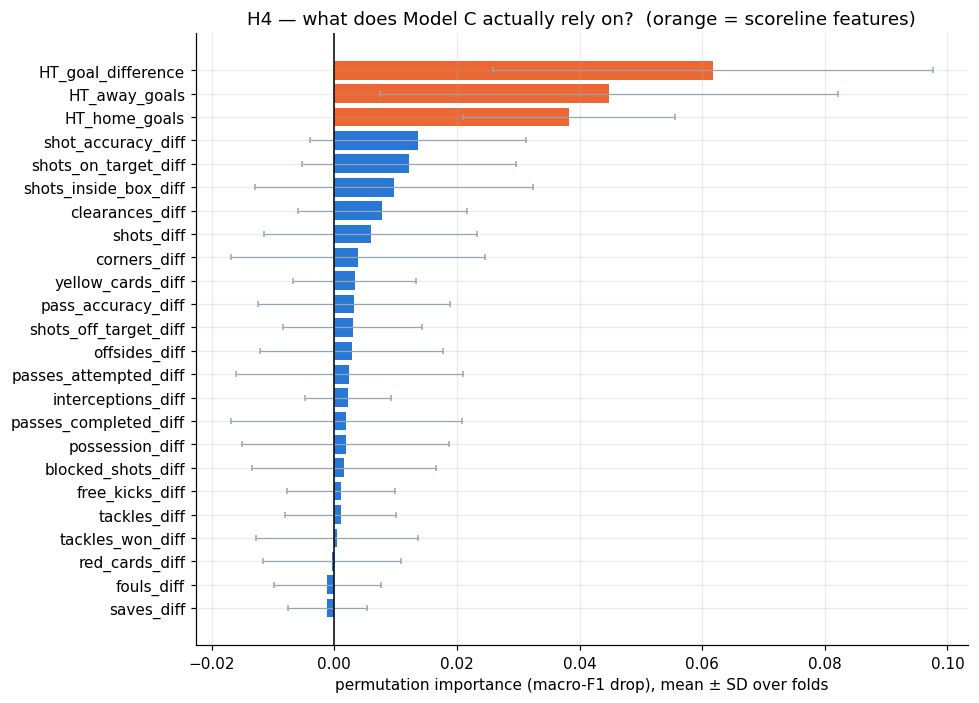

In [14]:
perm = pd.read_csv(RESULTS / "h4_permutation_summary.csv")
perm_fold = pd.read_csv(RESULTS / "h4_permutation_by_fold.csv")
abl = pd.read_csv(RESULTS / "h4_ablation.csv")

print("PERMUTATION IMPORTANCE on Model C -- mean over folds\n")
print(perm.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6.5))
p = perm.sort_values("mean_importance")
cols = [ORANGE if f.startswith("HT_") else BLUE for f in p.feature]
ax.barh(p.feature, p.mean_importance, xerr=p.sd_importance,
        color=cols, error_kw=dict(ecolor=GREY, capsize=2, lw=0.8))
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("permutation importance (macro-F1 drop), mean ± SD over folds")
ax.set_title("H4 — what does Model C actually rely on?  (orange = scoreline features)")
plt.tight_layout(); plt.show()

LEAVE-ONE-FEATURE-OUT ABLATION on Model C

delta_macro_f1 > 0 means removing the feature HURT the model (it was contributing)

              feature  full_macro_f1  ablated_macro_f1  delta_macro_f1  delta_macro_f1_sd  full_log_loss  ablated_log_loss  delta_log_loss
   HT_goal_difference         0.5863            0.5407          0.0456             0.0395         1.3454            1.3335         -0.0118
        HT_home_goals         0.5863            0.5513          0.0350             0.0229         1.3454            1.3595          0.0141
        HT_away_goals         0.5863            0.5653          0.0210             0.0417         1.3454            1.3488          0.0034
       red_cards_diff         0.5863            0.5768          0.0095             0.0338         1.3454            1.2529         -0.0925
   shot_accuracy_diff         0.5863            0.5775          0.0088             0.0216         1.3454            1.3197         -0.0256
shots_inside_box_diff         0.5863   

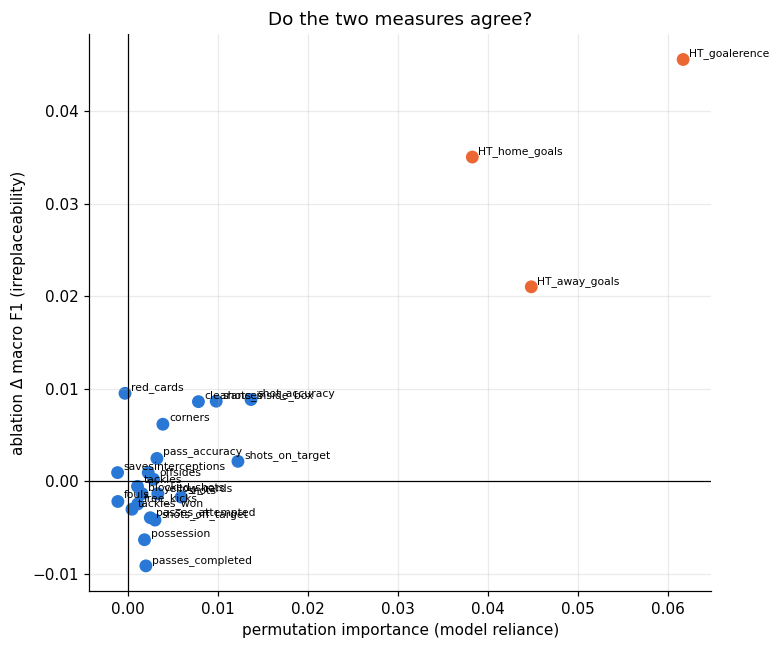


correlation between the two measures: r = 0.918


In [15]:
print("LEAVE-ONE-FEATURE-OUT ABLATION on Model C\n")
print("delta_macro_f1 > 0 means removing the feature HURT the model (it was contributing)\n")
print(abl.round(4).to_string(index=False))

merged = perm.merge(abl[["feature","delta_macro_f1","delta_log_loss"]], on="feature")
fig, ax = plt.subplots(figsize=(7.2, 6))
ax.scatter(merged.mean_importance, merged.delta_macro_f1, s=55,
           color=[ORANGE if f.startswith("HT_") else BLUE for f in merged.feature])
for _, r in merged.iterrows():
    ax.annotate(r.feature.replace("_diff",""), (r.mean_importance, r.delta_macro_f1),
                fontsize=7, xytext=(4,2), textcoords="offset points")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("permutation importance (model reliance)")
ax.set_ylabel("ablation Δ macro F1 (irreplaceability)")
ax.set_title("Do the two measures agree?")
plt.tight_layout(); plt.show()

r = merged[["mean_importance","delta_macro_f1"]].corr().iloc[0,1]
print(f"\ncorrelation between the two measures: r = {r:.3f}")

In [16]:
print("H4 ------------------------------------------------------------------")
low_perm = perm.nsmallest(6, "mean_importance").feature.tolist()
low_abl  = abl.nsmallest(6, "delta_macro_f1").feature.tolist()
both_low = [f for f in low_perm if f in low_abl]
print("lowest 6 by permutation importance:")
for f in low_perm: print("   ", f)
print("\nlowest 6 by ablation impact:")
for f in low_abl: print("   ", f)
print("\nindicators flagged as low-value by BOTH measures:")
for f in both_low: print("   ", f)
if not both_low:
    print("    (none -- the two measures disagree completely, which is itself the finding)")
print()
unstable = perm[(perm.folds_positive < perm.n_folds*0.6) & (perm.mean_importance > 0)]
print(f"features with positive mean importance but positive on fewer than 60% of folds "
      f"(i.e. unstable): {len(unstable)}")
if len(unstable):
    print("   ", ", ".join(unstable.feature.tolist()))
print()
print("VERDICT: H4 is answered by the intersection above. An indicator is only")
print("safely called 'low value' when BOTH measures agree AND it is stable across folds --")
print("a single measure on a single fit is exactly the claim §13 of the proposal warns against.")

H4 ------------------------------------------------------------------
lowest 6 by permutation importance:
    saves_diff
    fouls_diff
    red_cards_diff
    tackles_won_diff
    tackles_diff
    free_kicks_diff

lowest 6 by ablation impact:
    passes_completed_diff
    possession_diff
    shots_off_target_diff
    passes_attempted_diff
    tackles_won_diff
    free_kicks_diff

indicators flagged as low-value by BOTH measures:
    tackles_won_diff
    free_kicks_diff

features with positive mean importance but positive on fewer than 60% of folds (i.e. unstable): 11
    corners_diff, yellow_cards_diff, pass_accuracy_diff, shots_off_target_diff, offsides_diff, passes_attempted_diff, interceptions_diff, passes_completed_diff, possession_diff, free_kicks_diff, tackles_won_diff

VERDICT: H4 is answered by the intersection above. An indicator is only
safely called 'low value' when BOTH measures agree AND it is stable across folds --
a single measure on a single fit is exactly the claim §13

---
## 8. H5 — Which indicators survive the "Beyond the Scoreline" test?

> **Hypothesis.** Certain indicators remain predictive even after controlling
> for the half-time score.

This is the mirror image of H4, and the table it produces is the one the phrase
"beyond the scoreline" actually refers to. For every indicator $j$, a model is
built on **the scoreline plus that one indicator**, and compared against the
scoreline alone:

$$\Delta_j = \text{Performance}(\text{Score} + j) - \text{Performance}(\text{Score})$$

Building `Score + j` rather than removing $j$ from the full model is what makes
this different from H4: it isolates what an indicator contributes on its own
terms, without twenty correlated features already covering for it.

Score-only reference: macro F1 = 0.6073

INCREMENTAL VALUE -- Score + one indicator at a time

              feature  macro_f1  delta_macro_f1  delta_macro_f1_sd  log_loss  delta_log_loss  folds_improved  n_folds
 shots_on_target_diff    0.6168          0.0095             0.0206    0.9551         -0.0365               8       11
   pass_accuracy_diff    0.6140          0.0068             0.0271    0.9143          0.0043               6       11
         corners_diff    0.6130          0.0057             0.0221    0.9167          0.0018               6       11
      possession_diff    0.6127          0.0054             0.0279    0.9013          0.0173               5       11
           shots_diff    0.6120          0.0048             0.0160    0.9152          0.0034               7       11
passes_completed_diff    0.6119          0.0046             0.0289    0.8939          0.0247               5       11
passes_attempted_diff    0.6109          0.0036             0.0386    0.8943   

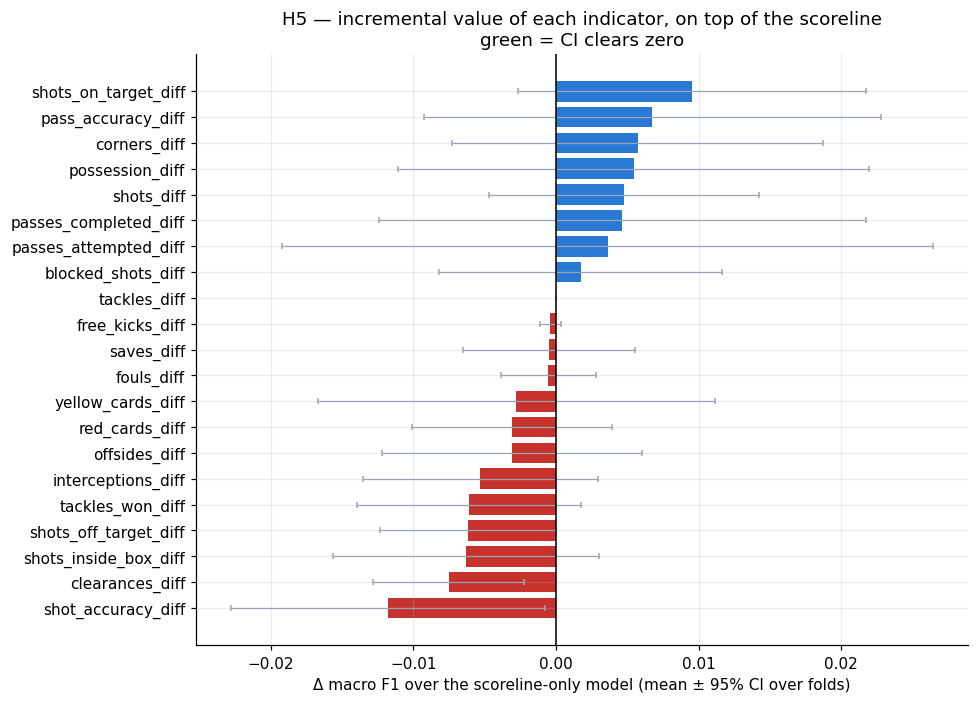

In [17]:
inc = pd.read_csv(RESULTS / "h5_incremental.csv")
base_f1 = float(inc.loc[inc.feature == "(score only)", "macro_f1"].iloc[0])
sweep = inc[inc.feature != "(score only)"].copy()

print(f"Score-only reference: macro F1 = {base_f1:.4f}\n")
print("INCREMENTAL VALUE -- Score + one indicator at a time\n")
print(inc.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6.5))
s = sweep.sort_values("delta_macro_f1")
ci = 1.96 * s.delta_macro_f1_sd / np.sqrt(s.n_folds)
ax.barh(s.feature, s.delta_macro_f1, xerr=ci,
        color=[GREEN if (v-c) > 0 else (BLUE if v > 0 else RED)
               for v, c in zip(s.delta_macro_f1, ci)],
        error_kw=dict(ecolor=GREY, capsize=2, lw=0.8))
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Δ macro F1 over the scoreline-only model (mean ± 95% CI over folds)")
ax.set_title("H5 — incremental value of each indicator, on top of the scoreline\n"
             "green = CI clears zero")
plt.tight_layout(); plt.show()

In [18]:
ci = 1.96 * sweep.delta_macro_f1_sd / np.sqrt(sweep.n_folds)
sweep["ci95"] = ci.values
sweep["clears_zero"] = sweep.delta_macro_f1 - sweep.ci95 > 0
sweep["majority_of_folds"] = sweep.folds_improved > sweep.n_folds / 2

survivors = sweep[sweep.clears_zero & sweep.majority_of_folds].sort_values(
    "delta_macro_f1", ascending=False)

print("H5 ------------------------------------------------------------------")
print(f"indicators tested                              : {len(sweep)}")
print(f"positive mean delta                            : {int((sweep.delta_macro_f1>0).sum())}")
print(f"improved on a majority of folds                : {int(sweep.majority_of_folds.sum())}")
print(f"95% CI clears zero                             : {int(sweep.clears_zero.sum())}")
print(f"BOTH (the 'beyond the scoreline' survivors)     : {len(survivors)}")
print()
if len(survivors):
    print("Indicators that retain predictive value above the half-time scoreline:\n")
    print(survivors[["feature","macro_f1","delta_macro_f1","ci95","folds_improved",
                     "n_folds","delta_log_loss"]].round(4).to_string(index=False))
    print()
    print("VERDICT: H5 SUPPORTED for the indicators listed above -- each improves on the")
    print("scoreline-only model by a margin whose confidence interval excludes zero, and")
    print("does so on most temporal folds rather than on a lucky one.")
else:
    print("VERDICT: H5 NOT SUPPORTED -- no single indicator improves on the scoreline-only")
    print("model by a margin that survives fold-to-fold variation. The scoreline absorbs")
    print("what the performance indicators have to say.")
print()
print("Cross-check against H4: an indicator should ideally appear near the TOP of the")
print("incremental sweep and be COSTLY to ablate. Where the two disagree, the usual cause")
print("is collinearity (§3.1) -- a feature that is individually informative but replaceable.")

H5 ------------------------------------------------------------------
indicators tested                              : 21
positive mean delta                            : 8
improved on a majority of folds                : 5
95% CI clears zero                             : 0
BOTH (the 'beyond the scoreline' survivors)     : 0

VERDICT: H5 NOT SUPPORTED -- no single indicator improves on the scoreline-only
model by a margin that survives fold-to-fold variation. The scoreline absorbs
what the performance indicators have to say.

Cross-check against H4: an indicator should ideally appear near the TOP of the
incremental sweep and be COSTLY to ablate. Where the two disagree, the usual cause
is collinearity (§3.1) -- a feature that is individually informative but replaceable.


The joint feature table -- the project's central feature-level result

              feature  H5_incremental  H4_ablation  mean_importance
 shots_on_target_diff          0.0095       0.0021           0.0122
   pass_accuracy_diff          0.0068       0.0025           0.0032
         corners_diff          0.0057       0.0062           0.0039
      possession_diff          0.0054      -0.0063           0.0018
           shots_diff          0.0048      -0.0017           0.0059
passes_completed_diff          0.0046      -0.0092           0.0020
passes_attempted_diff          0.0036      -0.0040           0.0025
   blocked_shots_diff          0.0017      -0.0013           0.0016
         tackles_diff          0.0000      -0.0006           0.0011
      free_kicks_diff         -0.0004      -0.0025           0.0011
           saves_diff         -0.0005       0.0009          -0.0012
           fouls_diff         -0.0005      -0.0022          -0.0011
    yellow_cards_diff         -0.0028      -0

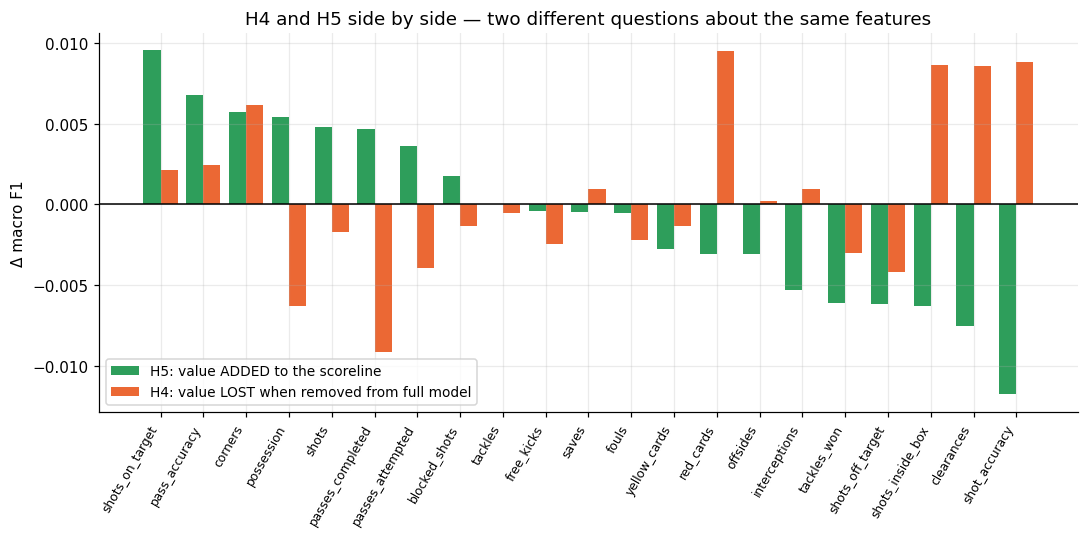

In [19]:
# H4 vs H5 side by side -- the two halves of the same question
cmp = (sweep[["feature","delta_macro_f1"]].rename(columns={"delta_macro_f1":"H5_incremental"})
       .merge(abl[["feature","delta_macro_f1"]].rename(columns={"delta_macro_f1":"H4_ablation"}),
              on="feature")
       .merge(perm[["feature","mean_importance"]], on="feature")
       .sort_values("H5_incremental", ascending=False))
print("The joint feature table -- the project's central feature-level result\n")
print(cmp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cmp))
ax.bar(x-0.2, cmp.H5_incremental, 0.4, color=GREEN, label="H5: value ADDED to the scoreline")
ax.bar(x+0.2, cmp.H4_ablation, 0.4, color=ORANGE, label="H4: value LOST when removed from full model")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f.replace("_diff","") for f in cmp.feature],
                                     rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Δ macro F1"); ax.legend(fontsize=9)
ax.set_title("H4 and H5 side by side — two different questions about the same features")
plt.tight_layout(); plt.show()

---
## 9. H5 — Do performance indicators interact with the half-time match state?

> **Hypothesis (H5).** The predictive contribution of half-time performance
> indicators varies according to the half-time match state.

**Note on numbering.** §8 above is labelled H5 in the original spec ("which
indicators survive the beyond-the-scoreline test"). The hypothesis stated here
is a different claim — an *interaction* — and is the one this section tests.
If the spec intends only one H5, these two sections need renumbering; they are
kept separate because they ask genuinely different questions.

### 9.1 Why the previous version of this section returned all zeros

The earlier implementation evaluated the §8 incremental sweep separately within
each half-time state, scoring with **macro F1**. It reported exactly `0.0000`
for all 21 indicators in both `Leading` and `Trailing`. That was not a bug in
the arithmetic — it is what the design guarantees:

* Within `Leading`, the home team wins 79.6% of the time. The scoreline-only
  model therefore predicts `H` for **every** match in that stratum.
* Macro F1 depends only on the **argmax**. Adding one performance indicator
  shifts the predicted probabilities, but never enough to flip a prediction in
  an already-decided stratum.
* Identical predictions ⇒ identical macro F1 ⇒ a delta of exactly zero.

So the old section could only ever detect an effect in `Drawing`, the one state
where the argmax is contestable — which is precisely the pattern it produced.
A metric that is blind to probability movement cannot test this hypothesis.

### 9.2 What this version does instead

Three changes, each fixing one defect:

| Defect | Fix |
|---|---|
| Macro F1 is argmax-only, so it is degenerate inside decided states | Score with **log loss**, a proper scoring rule that responds to probability movement even when no prediction flips |
| Per-fold stratification leaves ~27 matches per state per fold | Pool **out-of-fold** predictions across all 11 folds first, then stratify — the temporal guarantee is preserved because every prediction is still made by a model that never saw that match |
| Comparing three separate per-state deltas and eyeballing the differences is the "difference in significance ≠ significance of difference" error | Test the interaction **directly** with a likelihood-ratio test on `indicator × state` terms, giving one p-value per indicator for H5 itself |

Everything runs on the development block only (weeks < 33); the frozen holdout
is not touched. Multiplicity across the 21 indicators is controlled with
Benjamini–Hochberg.

In [20]:
# --- 9.3  Out-of-fold predictions, pooled across folds, stratified by state ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss
from scipy import stats

STATES  = ["Leading", "Drawing", "Trailing"]
CLASSES = ["A", "D", "H"]

# Fold boundaries rebuilt from match_week so this section reproduces the table
# printed in §3.2 without depending on protocol.py internals.
FOLD_SPECS = [((1, 10 + 2 * k), (11 + 2 * k, 12 + 2 * k)) for k in range(11)]

dev9   = dev.reset_index(drop=True).copy()
y9     = dev9["FT_result"].to_numpy()
state9 = dev9["HT_state_home"].to_numpy()
week9  = dev9["match_week"].to_numpy()


def _logit(**kw):
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, **kw))


def oof_probabilities(frame, cols):
    """Probabilities for every dev match, each produced by a model that
    trained only on earlier match-weeks. NaN where no fold covers the row."""
    P = np.full((len(frame), len(CLASSES)), np.nan)
    X = frame[cols].to_numpy(dtype=float)
    for (tr0, tr1), (te0, te1) in FOLD_SPECS:
        tr = (week9 >= tr0) & (week9 <= tr1)
        te = (week9 >= te0) & (week9 <= te1)
        if te.sum() == 0 or len(np.unique(y9[tr])) < len(CLASSES):
            continue
        m = _logit().fit(X[tr], y9[tr])
        order = [list(m.classes_).index(c) for c in CLASSES]
        P[te] = m.predict_proba(X[te])[:, order]
    return P


def per_match_nll(P, y):
    ci = {c: i for i, c in enumerate(CLASSES)}
    idx = np.array([ci[v] for v in y])
    return -np.log(np.clip(P[np.arange(len(y)), idx], 1e-12, 1.0))


P_score    = oof_probabilities(dev9, list(F.A_COLS))
covered    = ~np.isnan(P_score).any(axis=1)
nll_score  = per_match_nll(P_score, y9)
pred_score = np.array(CLASSES)[np.argmax(np.nan_to_num(P_score, nan=-1), axis=1)]

print(f"pooled out-of-fold predictions: {covered.sum()} of {len(dev9)} development matches\n")
print("Why the old macro-F1 design returned zeros — predictions inside each state:\n")
diag = []
for st in STATES:
    m = covered & (state9 == st)
    vals, cnts = np.unique(pred_score[m], return_counts=True)
    diag.append({"state": st, "n_matches": int(m.sum()),
                 "distinct_predicted_classes": int(len(vals)),
                 "prediction_mix": ", ".join(f"{v}:{c}" for v, c in zip(vals, cnts)),
                 "macro_f1_can_move": len(vals) > 1})
print(pd.DataFrame(diag).to_string(index=False))
print("\nWhere 'distinct_predicted_classes' is 1, no single feature can change the")
print("argmax, so any argmax-based delta is exactly 0 by construction — which is")
print("what §9.1 describes. Log loss below does not have this blind spot.")

pooled out-of-fold predictions: 878 of 1278 development matches

Why the old macro-F1 design returned zeros — predictions inside each state:

   state  n_matches  distinct_predicted_classes   prediction_mix  macro_f1_can_move
 Leading        291                           1            H:291              False
 Drawing        381                           3 A:1, D:94, H:286               True
Trailing        206                           1            A:206              False

Where 'distinct_predicted_classes' is 1, no single feature can change the
argmax, so any argmax-based delta is exactly 0 by construction — which is
what §9.1 describes. Log loss below does not have this blind spot.


In [21]:
# --- 9.4  Per-state incremental value, scored with log loss ------------------
MIN_N = 25   # minimum matches in a stratum before a delta is reported

state_rows, nll_by_feature = [], {}
for j in F.B_COLS:
    P_j   = oof_probabilities(dev9, list(F.A_COLS) + [j])
    nll_j = per_match_nll(P_j, y9)
    nll_by_feature[j] = nll_j
    ok_j = covered & ~np.isnan(P_j).any(axis=1)
    for st in STATES:
        m = ok_j & (state9 == st)
        if m.sum() < MIN_N:
            state_rows.append({"feature": j, "state": st, "n": int(m.sum()),
                               "delta_logloss": np.nan, "pct_improved": np.nan,
                               "wilcoxon_p": np.nan, "status": "too few matches"})
            continue
        d = nll_score[m] - nll_j[m]          # > 0  =>  indicator improves the fit
        if np.allclose(d, 0):
            p = 1.0
        else:
            p = stats.wilcoxon(d, zero_method="wilcox").pvalue
        state_rows.append({"feature": j, "state": st, "n": int(m.sum()),
                           "delta_logloss": d.mean(), "pct_improved": (d > 0).mean(),
                           "wilcoxon_p": p, "status": "ok"})

by_state = pd.DataFrame(state_rows)
by_state.to_csv(RESULTS / "h5_state_interaction_by_state.csv", index=False)

piv = by_state.pivot(index="feature", columns="state", values="delta_logloss")[STATES]
piv = piv.assign(spread=piv.max(axis=1) - piv.min(axis=1)).sort_values("spread", ascending=False)
print("Δ log loss from adding one indicator to the scoreline, by half-time state")
print("(positive = the indicator improves prediction; 'spread' = max − min across states)\n")
print(piv.round(4).to_string())

Δ log loss from adding one indicator to the scoreline, by half-time state
(positive = the indicator improves prediction; 'spread' = max − min across states)

state                  Leading  Drawing  Trailing  spread
feature                                                  
shots_diff             -0.0067   0.0198    0.0108  0.0265
passes_completed_diff   0.0103   0.0229    0.0363  0.0260
shots_inside_box_diff  -0.0044   0.0060    0.0198  0.0242
blocked_shots_diff     -0.0063   0.0176   -0.0047  0.0239
passes_attempted_diff   0.0111   0.0216    0.0347  0.0236
possession_diff         0.0058   0.0184    0.0247  0.0189
pass_accuracy_diff      0.0045   0.0144    0.0220  0.0175
corners_diff           -0.0071   0.0062    0.0068  0.0139
shots_off_target_diff  -0.0048   0.0089    0.0091  0.0139
yellow_cards_diff       0.0005   0.0058   -0.0052  0.0109
saves_diff              0.0011   0.0033    0.0113  0.0102
shots_on_target_diff   -0.0009   0.0026    0.0091  0.0099
red_cards_diff          0.0124

In [22]:
# --- 9.5  The interaction test itself ----------------------------------------
# H5 is an interaction claim, so it is tested as one: a likelihood-ratio test of
# indicator x state terms against the same model without them. Testing each
# state separately and comparing significance would be the classic
# "difference in significance is not significance of difference" error.

K_FREE = len(CLASSES) - 1          # identified equations in a 3-class multinomial


def _design(frame, j, interaction):
    d_lead  = (frame["HT_state_home"] == "Leading").to_numpy(float)
    d_trail = (frame["HT_state_home"] == "Trailing").to_numpy(float)
    x = frame[j].to_numpy(float)
    blocks = [frame[list(F.A_COLS)].to_numpy(float),
              d_lead[:, None], d_trail[:, None], x[:, None]]
    if interaction:
        blocks += [(x * d_lead)[:, None], (x * d_trail)[:, None]]
    return np.hstack(blocks)


def _loglik(X, y):
    Xs = StandardScaler().fit_transform(X)
    try:
        m = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(Xs, y)
    except (TypeError, ValueError):                    # older sklearn
        m = LogisticRegression(C=1e8, solver="lbfgs", max_iter=5000).fit(Xs, y)
    return -log_loss(y, m.predict_proba(Xs), labels=list(m.classes_), normalize=False)


inter_rows = []
for j in F.B_COLS:
    ll0 = _loglik(_design(dev9, j, False), y9)
    ll1 = _loglik(_design(dev9, j, True),  y9)
    lr  = max(2.0 * (ll1 - ll0), 0.0)
    df  = 2 * K_FREE               # 2 interaction terms x 2 free equations
    inter_rows.append({"feature": j, "LR_stat": lr, "df": df,
                       "p_value": float(stats.chi2.sf(lr, df))})

inter = pd.DataFrame(inter_rows).sort_values("p_value").reset_index(drop=True)

# Benjamini-Hochberg across the 21 indicators
m_tests = len(inter)
inter["bh_threshold"] = (np.arange(1, m_tests + 1) / m_tests) * 0.05
below = inter.p_value.to_numpy() <= inter.bh_threshold.to_numpy()
inter["significant_bh"] = False
if below.any():
    inter.loc[: int(np.max(np.where(below)[0])), "significant_bh"] = True
inter.to_csv(RESULTS / "h5_state_interaction_test.csv", index=False)

print("H5 interaction test — likelihood-ratio, indicator x half-time state")
print("(fitted on the development block only; the frozen holdout is untouched)\n")
print(inter.round(4).to_string(index=False))

H5 interaction test — likelihood-ratio, indicator x half-time state
(fitted on the development block only; the frozen holdout is untouched)

              feature  LR_stat  df  p_value  bh_threshold  significant_bh
   blocked_shots_diff   9.3074   4   0.0539        0.0024           False
       red_cards_diff   4.6745   4   0.3224        0.0048           False
   pass_accuracy_diff   4.4149   4   0.3528        0.0071           False
           shots_diff   4.2703   4   0.3707        0.0095           False
      clearances_diff   3.4771   4   0.4814        0.0119           False
      free_kicks_diff   2.8219   4   0.5881        0.0143           False
   interceptions_diff   2.5293   4   0.6394        0.0167           False
    yellow_cards_diff   2.4234   4   0.6584        0.0190           False
           fouls_diff   2.3042   4   0.6800        0.0214           False
      possession_diff   2.3025   4   0.6803        0.0238           False
           saves_diff   2.2365   4   0.6924  

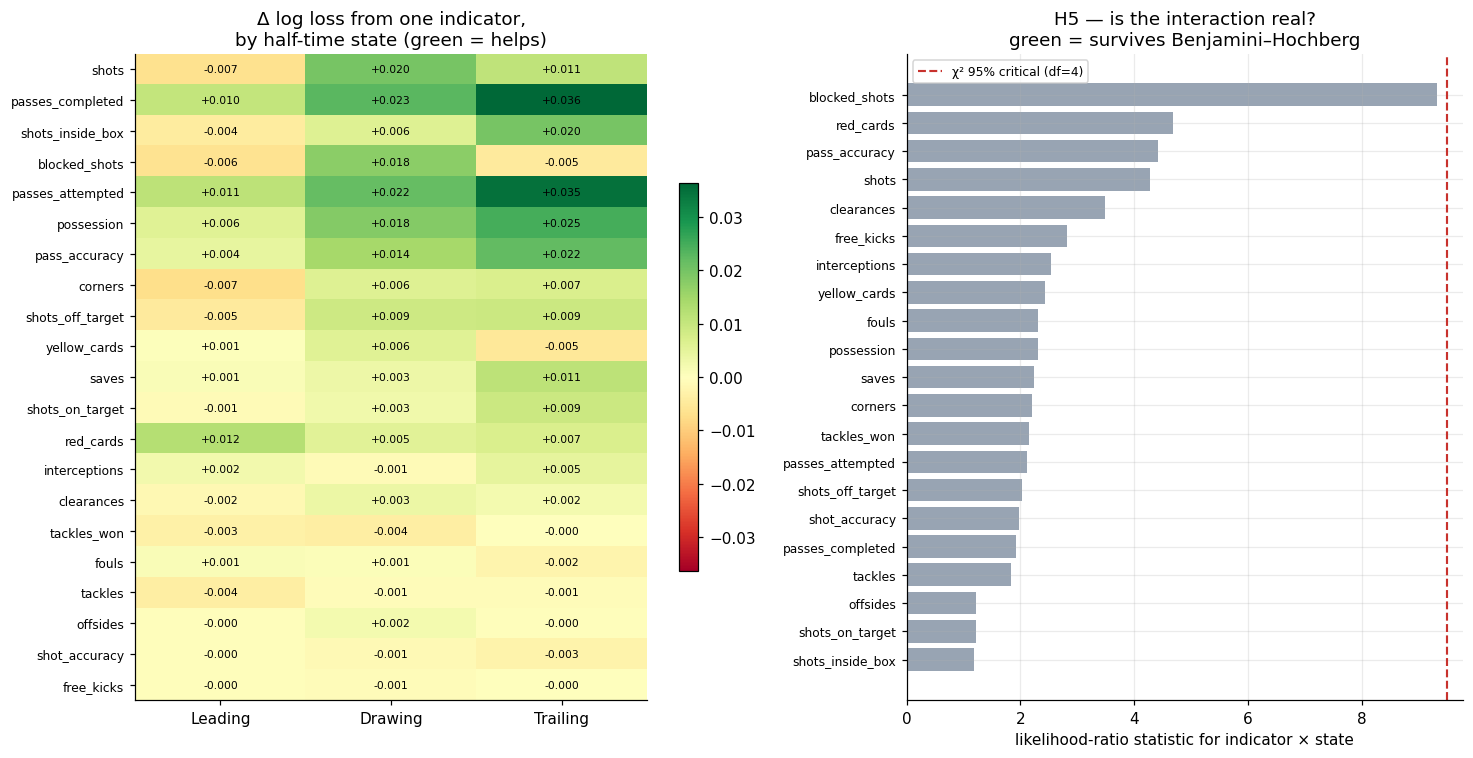

In [23]:
# --- 9.6  Figures -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 7),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
hm = piv[STATES]
v = np.nanmax(np.abs(hm.values)) or 1.0
im = ax.imshow(hm.values, cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
ax.set_xticks(range(len(STATES))); ax.set_xticklabels(STATES)
ax.set_yticks(range(len(hm)))
ax.set_yticklabels([f.replace("_diff", "") for f in hm.index], fontsize=8)
for i in range(hm.shape[0]):
    for k in range(hm.shape[1]):
        if not np.isnan(hm.values[i, k]):
            ax.text(k, i, f"{hm.values[i, k]:+.3f}", ha="center", va="center", fontsize=7)
ax.set_title("Δ log loss from one indicator,\nby half-time state (green = helps)")
ax.grid(False); plt.colorbar(im, ax=ax, shrink=0.6)

ax = axes[1]
s = inter.sort_values("LR_stat")
cols = [GREEN if sig else GREY for sig in s.significant_bh]
ax.barh([f.replace("_diff", "") for f in s.feature], s.LR_stat, color=cols)
ax.axvline(stats.chi2.ppf(0.95, 2 * K_FREE), color=RED, ls="--", lw=1.4,
           label=f"χ² 95% critical (df={2*K_FREE})")
ax.set_xlabel("likelihood-ratio statistic for indicator × state")
ax.set_title("H5 — is the interaction real?\ngreen = survives Benjamini–Hochberg")
ax.legend(fontsize=8); ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

In [24]:
# --- 9.7  Verdict -------------------------------------------------------------
print("H5 ------------------------------------------------------------------")
n_raw = int((inter.p_value < 0.05).sum())
n_bh  = int(inter.significant_bh.sum())
print(f"indicators tested                          : {len(inter)}")
print(f"interaction significant at p<0.05 (raw)    : {n_raw}/{len(inter)}")
print(f"interaction surviving Benjamini-Hochberg   : {n_bh}/{len(inter)}")
print()

usable = by_state[by_state.status == "ok"]
print("Matches available per state (pooled out-of-fold):")
print(usable.groupby("state").n.max().reindex(STATES).to_string())
print()

if n_bh:
    print("Indicators whose contribution DOES depend on the half-time state:\n")
    for _, r in inter[inter.significant_bh].iterrows():
        row = piv.loc[r.feature]
        best = row[STATES].idxmax()
        print(f"  {r.feature:24s} LR={r.LR_stat:6.2f}  p={r.p_value:.4f}   "
              f"strongest when {best}  ("
              + ", ".join(f"{s}:{row[s]:+.3f}" for s in STATES) + ")")
    print()
    print("VERDICT: H5 SUPPORTED for the indicators above — the likelihood-ratio test")
    print("rejects a constant effect across half-time states, after correcting for")
    print("testing 21 indicators.")
else:
    print("VERDICT: H5 NOT SUPPORTED — no indicator's contribution varies across")
    print("half-time states by a margin that survives multiplicity correction. Note")
    print("this is now a real null result rather than the artefact the previous")
    print("macro-F1 implementation produced: log loss can see probability movement")
    print("inside decided states, and it still finds no reliable interaction.")
print()
print("Read alongside §7 and §8: those ask whether an indicator matters at all;")
print("this asks whether it matters *differently* depending on the scoreline it is")
print("read against. An indicator can pass one and fail the other.")

H5 ------------------------------------------------------------------
indicators tested                          : 21
interaction significant at p<0.05 (raw)    : 0/21
interaction surviving Benjamini-Hochberg   : 0/21

Matches available per state (pooled out-of-fold):
state
Leading     291
Drawing     381
Trailing    206

VERDICT: H5 NOT SUPPORTED — no indicator's contribution varies across
half-time states by a margin that survives multiplicity correction. Note
this is now a real null result rather than the artefact the previous
macro-F1 implementation produced: log loss can see probability movement
inside decided states, and it still finds no reliable interaction.

Read alongside §7 and §8: those ask whether an indicator matters at all;
this asks whether it matters *differently* depending on the scoreline it is
read against. An indicator can pass one and fail the other.


---
## 10. Algorithm comparison

Only now, after the hypotheses are answered, do the algorithms get compared —
they are a methodological component of this study, not its research question.

mean macro F1 by algorithm and feature set

feature_set              A       B       C    mean
algorithm                                         
NaiveBayes          0.6073  0.4714  0.5863  0.5550
SVM                 0.5548  0.5095  0.5562  0.5402
DecisionTree        0.5894  0.4377  0.5710  0.5327
LogisticRegression  0.5374  0.5219  0.5363  0.5319
RandomForest        0.5519  0.4469  0.5595  0.5195
kNN                 0.5639  0.4165  0.5202  0.5002


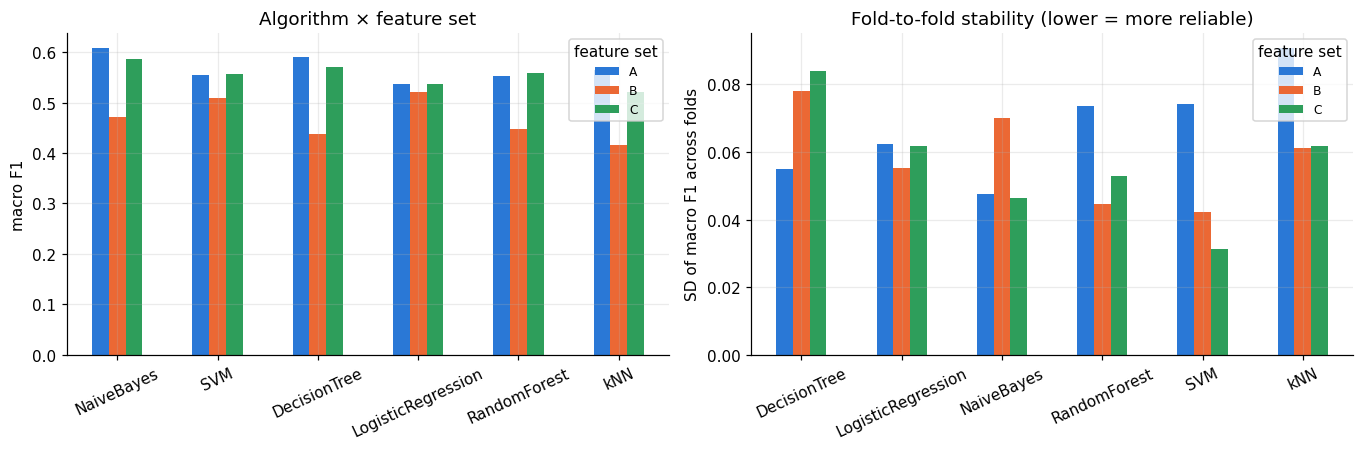


most accurate overall : NaiveBayes
most stable on Model C: SVM (SD 0.0311)


In [25]:
algo_tbl = (res.groupby(["algorithm","feature_set"]).macro_f1.mean().unstack()
            .assign(mean=lambda d: d.mean(axis=1)).sort_values("mean", ascending=False).round(4))
print("mean macro F1 by algorithm and feature set\n")
print(algo_tbl.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
algo_tbl[["A","B","C"]].plot(kind="bar", ax=axes[0], color=[BLUE, ORANGE, GREEN])
axes[0].set_ylabel("macro F1"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25); axes[0].legend(title="feature set", fontsize=8)
axes[0].set_title("Algorithm × feature set")

spread = res.groupby(["algorithm","feature_set"]).macro_f1.std().unstack()
spread.plot(kind="bar", ax=axes[1], color=[BLUE, ORANGE, GREEN])
axes[1].set_ylabel("SD of macro F1 across folds"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25); axes[1].legend(title="feature set", fontsize=8)
axes[1].set_title("Fold-to-fold stability (lower = more reliable)")
plt.tight_layout(); plt.show()

print(f"\nmost accurate overall : {algo_tbl['mean'].idxmax()}")
print(f"most stable on Model C: {spread['C'].idxmin()} (SD {spread['C'].min():.4f})")

---
## 11. The frozen held-out evaluation

Match-weeks 33+ played no part in any decision above — not feature
engineering, not model selection, not hypothesis development. The pipeline was
frozen, then run against them once. This is the closest thing here to a genuine
out-of-sample deployment test.

In [26]:
hres = pd.read_csv(RESULTS / "holdout_results.csv")
hbase = pd.read_csv(RESULTS / "holdout_baselines.csv")
hmc = pd.read_csv(RESULTS / "holdout_mcnemar.csv")
hconf = pd.read_csv(RESULTS / "holdout_confusion.csv")
hcal = pd.read_csv(RESULTS / "holdout_calibration.csv")

print(f"frozen holdout: {len(holdout)} matches, weeks {holdout.match_week.min()}"
      f"-{holdout.match_week.max()}\n")
piv = (hres.pivot_table(index="algorithm", columns="feature_set",
                        values=["accuracy","macro_f1","log_loss"]).round(4))
print(piv.to_string())
print("\nbaselines on the same matches:")
print(hbase[["baseline","accuracy","macro_f1"]].round(4).to_string(index=False))

best = hres.sort_values("macro_f1", ascending=False).groupby("feature_set").head(1)
print("\nbest algorithm per feature set on the frozen block:")
print(best[["feature_set","algorithm","accuracy","macro_precision","macro_recall",
            "macro_f1","weighted_f1","log_loss","roc_auc_macro","brier"]]
      .round(4).to_string(index=False))

frozen holdout: 239 matches, weeks 33-38

                   accuracy                 log_loss                 macro_f1                
feature_set               A       B       C        A       B       C        A       B       C
algorithm                                                                                    
DecisionTree         0.6151  0.5690  0.6276   0.7796  0.9700  0.7806   0.6100  0.4982  0.5965
LogisticRegression   0.6192  0.5900  0.6067   0.7861  0.8282  0.7899   0.5375  0.4955  0.5296
NaiveBayes           0.6151  0.4644  0.5649   0.8908  1.5704  1.3728   0.6100  0.4221  0.5368
RandomForest         0.6151  0.5481  0.6109   0.7923  0.9381  0.8225   0.6100  0.4545  0.5500
SVM                  0.6151  0.5983  0.5983   0.8415  0.8507  0.8275   0.6100  0.5296  0.5443
kNN                  0.6067  0.4854  0.6192   0.8099  1.4198  0.8587   0.5989  0.4153  0.5487

baselines on the same matches:
            baseline  accuracy  macro_f1
      majority_class    0.5021    0.222

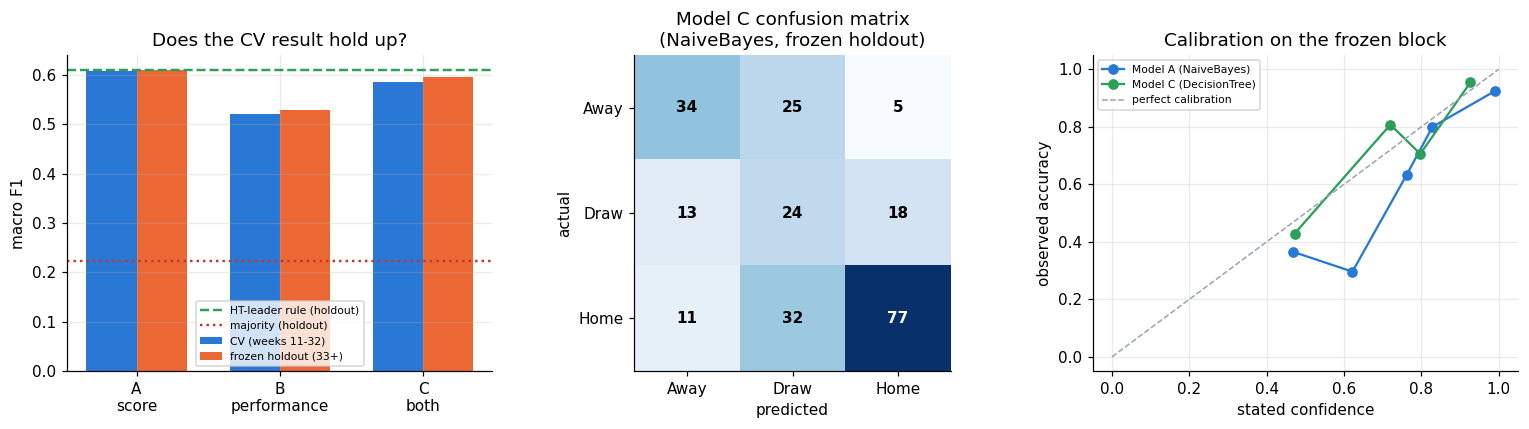

H3 re-tested on the frozen block (McNemar, C vs A):
         algorithm  accuracy_A  accuracy_C  delta_accuracy  p_value
LogisticRegression      0.6192      0.6067         -0.0126   0.7194
        NaiveBayes      0.6151      0.5649         -0.0502   0.1624
      DecisionTree      0.6151      0.6276          0.0126   0.7003
      RandomForest      0.6151      0.6109         -0.0042   1.0000
               SVM      0.6151      0.5983         -0.0167   0.6650
               kNN      0.6067      0.6192          0.0126   0.7979

significant favouring C: 0/6


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
w = 0.35; x = np.arange(3)
cv_best = [A.macro_f1.max(), B.macro_f1.max(), C.macro_f1.max()]
ho_best = [best[best.feature_set==s].macro_f1.iloc[0] for s in ["A","B","C"]]
ax.bar(x-w/2, cv_best, w, color=BLUE, label="CV (weeks 11-32)")
ax.bar(x+w/2, ho_best, w, color=ORANGE, label="frozen holdout (33+)")
ax.axhline(hbase[hbase.baseline=="halftime_leader_rule"].macro_f1.iloc[0],
           color=GREEN, ls="--", lw=1.6, label="HT-leader rule (holdout)")
ax.axhline(hbase[hbase.baseline=="majority_class"].macro_f1.iloc[0],
           color=RED, ls=":", lw=1.6, label="majority (holdout)")
ax.set_xticks(x); ax.set_xticklabels(["A\nscore","B\nperformance","C\nboth"])
ax.set_ylabel("macro F1"); ax.set_title("Does the CV result hold up?"); ax.legend(fontsize=7)

ax = axes[1]
sc = hconf[hconf.feature_set=="C"]
cm = sc.pivot(index="actual", columns="predicted", values="n").reindex(
    index=["A","D","H"], columns=["A","D","H"]).fillna(0).values
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(["Away","Draw","Home"])
ax.set_yticks(range(3)); ax.set_yticklabels(["Away","Draw","Home"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(cm[i,j]), ha="center", va="center",
                color="white" if cm[i,j] > cm.max()*0.6 else "black", fontweight="bold")
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.grid(False)
ax.set_title(f"Model C confusion matrix\n({sc.algorithm.iloc[0]}, frozen holdout)")

ax = axes[2]
for set_name, colour in (("A", BLUE), ("C", GREEN)):
    algo = best[best.feature_set==set_name].algorithm.iloc[0]
    cb = hcal[(hcal.feature_set==set_name) & (hcal.algorithm==algo)]
    ax.plot(cb.mean_confidence, cb.observed_accuracy, marker="o", color=colour,
            label=f"Model {set_name} ({algo})")
ax.plot([0,1],[0,1], ls="--", color=GREY, lw=1, label="perfect calibration")
ax.set_xlabel("stated confidence"); ax.set_ylabel("observed accuracy")
ax.set_title("Calibration on the frozen block"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("H3 re-tested on the frozen block (McNemar, C vs A):")
print(hmc[["algorithm","accuracy_A","accuracy_C","delta_accuracy","p_value"]]
      .round(4).to_string(index=False))
print(f"\nsignificant favouring C: "
      f"{int(((hmc.p_value<0.05)&(hmc.delta_accuracy>0)).sum())}/6")

In [28]:
over = []
for set_name in ["A","B","C"]:
    algo = best[best.feature_set==set_name].algorithm.iloc[0]
    cb = hcal[(hcal.feature_set==set_name) & (hcal.algorithm==algo)]
    w_ = cb.n / cb.n.sum()
    over.append({"feature_set": set_name, "algorithm": algo,
                 "mean_confidence": float((cb.mean_confidence*w_).sum()),
                 "observed_accuracy": float((cb.observed_accuracy*w_).sum())})
over = pd.DataFrame(over)
over["overconfidence"] = (over.mean_confidence - over.observed_accuracy).round(4)
print("Probability quality on the frozen block\n")
print(over.round(4).to_string(index=False))
print()
if (over.overconfidence > 0.05).any():
    print("These models state more confidence than they earn. Accuracy and macro F1 should")
    print("always be reported alongside log loss and Brier for exactly this reason -- a model")
    print("can be right often enough while still being untrustworthy at its stated confidence.")
else:
    print("Stated confidence and observed accuracy are closely matched -- these probabilities")
    print("can be taken at face value.")

Probability quality on the frozen block

feature_set    algorithm  mean_confidence  observed_accuracy  overconfidence
          A   NaiveBayes           0.7215             0.6151          0.1065
          B          SVM           0.5601             0.5858         -0.0257
          C DecisionTree           0.6330             0.6276          0.0054

These models state more confidence than they earn. Accuracy and macro F1 should
always be reported alongside log loss and Brier for exactly this reason -- a model
can be right often enough while still being untrustworthy at its stated confidence.


---
## 12. Master result matrix and conclusions

In [29]:
master = pd.DataFrame([
    {"Hypothesis": "H1", "Experiment": "Model A vs baselines",
     "Primary evidence": f"macro F1 {A.macro_f1.max():.4f} (best: {A.macro_f1.idxmax()})",
     "Secondary": f"accuracy {A.accuracy.max():.4f}; majority {maj_f1:.4f}; rule {rule_f1:.4f}"},
    {"Hypothesis": "H2", "Experiment": "Model B (no score)",
     "Primary evidence": f"macro F1 {B.macro_f1.max():.4f} (best: {B.macro_f1.idxmax()})",
     "Secondary": f"accuracy {B.accuracy.max():.4f}; vs A {B.macro_f1.max()-A.macro_f1.max():+.4f}"},
    {"Hypothesis": "H3", "Experiment": "A vs C + McNemar",
     "Primary evidence": f"mean Δ macro F1 {delta.delta_macro_f1.mean():+.4f}; "
                         f"significant {int((mc.p_value<0.05).sum())}/6",
     "Secondary": f"mean Δ log loss {delta.delta_log_loss.mean():+.4f}"},
    {"Hypothesis": "H4", "Experiment": "permutation + ablation",
     "Primary evidence": f"lowest-value by both measures: {len(both_low)} indicators",
     "Secondary": f"measure agreement r = {r:.3f}"},
    {"Hypothesis": "H5", "Experiment": "Score + individual feature",
     "Primary evidence": f"{len(survivors)} indicators clear zero on CI and majority of folds",
     "Secondary": f"best: {survivors.feature.iloc[0] if len(survivors) else 'none'}"},
])
print(master.to_string(index=False))

print("\n" + "="*78)
print("SUMMARY OF FINDINGS")
print("="*78)

hold_c = best[best.feature_set=="C"].macro_f1.iloc[0]
hold_rule = hbase[hbase.baseline=="halftime_leader_rule"].macro_f1.iloc[0]
n_sig_c = int(((mc.p_value<0.05)&(mc.delta_accuracy>0)).sum())

print()
print(f"Data     {len(matches):,} matches, {matches.competition.nunique()} leagues, "
      f"{matches.season.iloc[0]}, rebuilt from StatsBomb event data")
print(f"         with an exact half-time cut. {len(F.B_COLS)} performance indicators, including")
print( "         tackles, interceptions, clearances and saves that no conventional")
print( "         match-results dataset carries.")
print()
print(f"H1       Model A (3 scoreline features) reaches macro F1 {A.macro_f1.max():.4f},")
print(f"         against a majority baseline of {maj_f1:.4f} and a half-time-leader")
print(f"         rule of {rule_f1:.4f}.")
print()
print(f"H2       Model B ({len(F.B_COLS)} performance features, no score) reaches {B.macro_f1.max():.4f} --")
print(f"         {'above' if B.macro_f1.max() > maj_f1 else 'at or below'} the baseline, and "
      f"{abs(B.macro_f1.max()-A.macro_f1.max()):.4f} "
      f"{'above' if B.macro_f1.max() > A.macro_f1.max() else 'below'} Model A.")
print()
print(f"H3       Adding performance to the scoreline changes macro F1 by "
      f"{delta.delta_macro_f1.mean():+.4f} on")
print(f"         average; McNemar finds {n_sig_c}/6 algorithms significantly improved.")
print()
print(f"H4/H5    Permutation importance and ablation agree on {len(both_low)} low-value indicators;")
print(f"         {len(survivors)} indicators add value to the scoreline that survives")
print( "         fold-to-fold variation.")
print()
print(f"Holdout  On {len(holdout)} matches frozen out of the entire development process,")
print(f"         the best Model C scores {hold_c:.4f} against a half-time-leader")
print(f"         rule of {hold_rule:.4f}.")

Hypothesis                 Experiment                                    Primary evidence                                     Secondary
        H1       Model A vs baselines                  macro F1 0.6073 (best: NaiveBayes) accuracy 0.6105; majority 0.2020; rule 0.6073
        H2         Model B (no score)          macro F1 0.5219 (best: LogisticRegression)                 accuracy 0.5821; vs A -0.0854
        H3           A vs C + McNemar            mean Δ macro F1 -0.0125; significant 0/6                       mean Δ log loss -0.2198
        H4     permutation + ablation         lowest-value by both measures: 2 indicators                   measure agreement r = 0.918
        H5 Score + individual feature 0 indicators clear zero on CI and majority of folds                                    best: none

SUMMARY OF FINDINGS

Data     1,517 matches, 4 leagues, 2015/2016, rebuilt from StatsBomb event data
         with an exact half-time cut. 21 performance indicators, including
       

### What "Beyond the Scoreline" ends up meaning

The phrase has a precise methodological meaning in this study: an indicator
earns the label only if it improves prediction **on top of** the half-time
score, by a margin that survives fold-to-fold variation, and it should do so
under both of the independent feature measures rather than one.

That is a much harder bar than "this feature had high importance in a random
forest", and it is the bar the tables in §7 and §8 apply.

### Limitations, stated plainly

* **One season, four leagues.** The rebuilt dataset is rich in features but
  covers a single season, because that is the extent of StatsBomb's complete
  league coverage. Temporal validation therefore runs within-season by
  match-week rather than across seasons.
* **The frozen holdout is a late-season block.** Late-season matches are not a
  random sample of matches — motivation varies once titles and relegation are
  settled — so the holdout is an honest future test, not an unbiased one.
* **Collinearity limits what ablation can prove.** Within the passing and
  possession block especially, removing one feature leaves close substitutes
  behind. A small ablation delta means "replaceable", not "irrelevant" — §7
  and §8 are read together for that reason.
* **Half-time performance is measured, half-time context is not.** Team
  strength, form and fixture context are outside this dataset's scope, so the
  study measures what the state of play adds, not what a complete pre-match
  model would.

### Reproducing everything

```bash
cd Final_hypo/src
python ingest.py        # rebuild the dataset from StatsBomb events
python features.py      # A / B / C feature sets
python train.py         # 18 configurations + baselines + McNemar (H1, H2, H3)
python run_features.py  # permutation, ablation, incremental sweep (H4, H5, §9)
python final_eval.py    # the frozen held-out evaluation
```


---
## 13. Extension — does the answer change between league and knockout football?

Every result so far comes from league matches. This section asks whether they
hold up in knockout football, using StatsBomb's own `competition_stage` label
(Group vs Knockout) on the four tournaments the archive covers completely —
FIFA World Cup, UEFA Euro, Women's World Cup, Women's Euro — combined with the
four 2015/16 leagues used throughout.

**The confound, stated up front.** "League" here means club football and
"Knockout" means international tournaments, so format and level of competition
are entangled if compared directly. The control is the tournaments' own
**group-stage** matches — same teams, same tournaments, same era as the
knockout matches, differing only in format. League vs. tournament-group is
reported too, but it is the weaker comparison (format roughly fixed, level of
competition differs), and is read as background rather than as evidence about
format.

**A caveat that stays true no matter what the numbers say:** knockout samples
here are in the low hundreds, not the thousands the league analysis has. Any
difference below is a candidate finding, not a settled one.

In [30]:
import format_comparison as FC

combined = FC.load_combined()
print(f"combined dataset: {len(combined)} matches")
print(combined.groupby('stage').size().rename('matches').to_string())
print()
print("competitions contributing knockout matches:")
print(combined[combined.stage=='Knockout'].competition.value_counts().to_string())
print()
print("competitions contributing group-stage matches:")
print(combined[combined.stage=='Group'].competition.value_counts().to_string())

combined dataset: 1944 matches
stage
Group        309
Knockout     118
League      1517

competitions contributing knockout matches:
competition
FIFA World Cup       42
Women's World Cup    32
UEFA Euro            30
UEFA Women's Euro    14

competitions contributing group-stage matches:
competition
FIFA World Cup       105
Women's World Cup     84
UEFA Euro             72
UEFA Women's Euro     48


### 13.1 Does a half-time lead survive at the same rate?

   stage ht_state   n  away_win  draw  home_win
  League  Leading 515     0.060 0.144     0.796
  League  Drawing 648     0.239 0.395     0.366
  League Trailing 354     0.718 0.203     0.079
   Group  Leading  99     0.091 0.101     0.808
   Group  Drawing 136     0.324 0.294     0.382
   Group Trailing  74     0.770 0.162     0.068
Knockout  Leading  34     0.000 0.118     0.882
Knockout  Drawing  57     0.175 0.246     0.579
Knockout Trailing  27     0.667 0.185     0.148


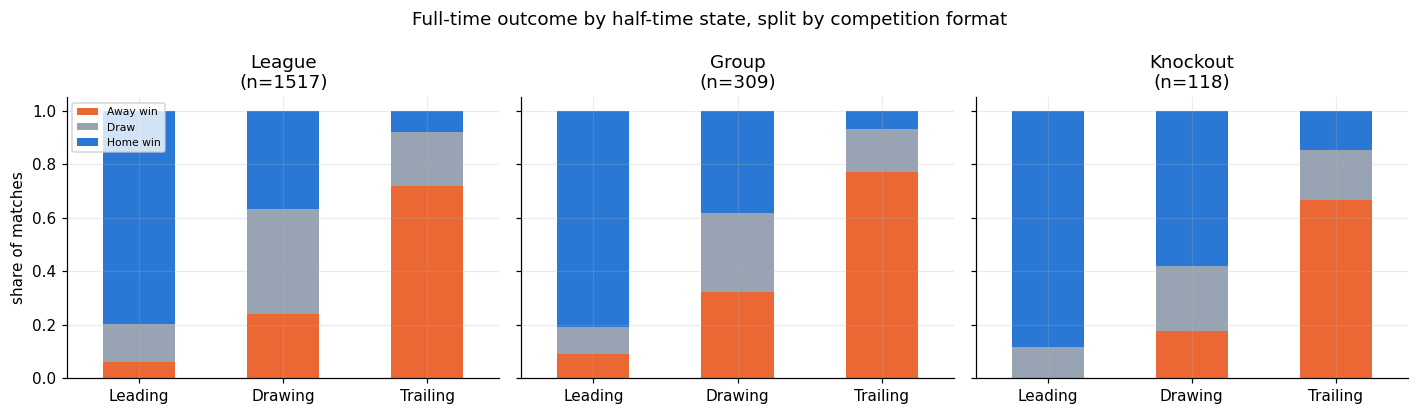

In [31]:
tt = FC.transition_table(combined)
print(tt.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, stage in zip(axes, ["League", "Group", "Knockout"]):
    sub = tt[tt.stage == stage].set_index("ht_state").reindex(["Leading","Drawing","Trailing"])
    if sub.empty or sub.n.isna().all():
        ax.set_visible(False); continue
    sub[["away_win","draw","home_win"]].plot(kind="bar", stacked=True, ax=ax,
                                              color=[ORANGE, GREY, BLUE], legend=False)
    ax.set_title(f"{stage}\n(n={int(sub.n.sum())})"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("share of matches"); axes[0].legend(["Away win","Draw","Home win"], fontsize=7)
plt.suptitle("Full-time outcome by half-time state, split by competition format")
plt.tight_layout(); plt.show()

In [32]:
chi = FC.lead_survival_chi2(combined)
print("Home half-time lead -> does it hold to full time?\n")
print(chi["table"].to_string())
print(f"\nhold rate by stage:\n{chi['hold_rate'].round(3).to_string()}")
print(f"\nchi2 = {chi['chi2']:.3f}, dof = {chi['dof']}, p = {chi['p_value']:.4f}")
print()
if chi["p_value"] < 0.05:
    spread = chi["hold_rate"].max() - chi["hold_rate"].min()
    lowest = chi["hold_rate"].idxmin()
    print(f"FINDING: half-time-lead survival is NOT independent of format (p<0.05).")
    print(f"Spread across formats: {spread:.3f}. Leads are least secure in: {lowest}.")
    print("This is consistent with the intuition that a knockout tie is fought between more")
    print("evenly matched sides, and/or that a team content to reach extra time plays")
    print("differently from one chasing league points -- the data cannot distinguish those")
    print("two mechanisms, only that the survival rate itself differs.")
else:
    print("FINDING: no significant difference in how often a half-time lead holds across")
    print("league, group-stage and knockout football on this sample.")

Home half-time lead -> does it hold to full time?

held      False  True 
stage                 
League      105    410
Group        19     80
Knockout      4     30

hold rate by stage:
stage
League      0.796
Group       0.808
Knockout    0.882

chi2 = 1.520, dof = 2, p = 0.4678

FINDING: no significant difference in how often a half-time lead holds across
league, group-stage and knockout football on this sample.


### 13.2 Is the scoreline a weaker predictor in knockout football?

If knockout matches really are more evenly contested, Model A should score
lower there than in league matches — there is less for the scoreline alone to
separate. Model A and Model C are refit and evaluated **separately within each
stage** (grouped by competition+season, so no fold is tested on the exact
tournament edition it trained on), rather than reusing the league-only fit from
§4/§6 above.

best macro F1 per stage, Model A vs Model C (separate fit per stage)

feature_set       A       C
stage                      
League       0.6043  0.5626
Group        0.4789  0.5137
Knockout     0.4937  0.4946


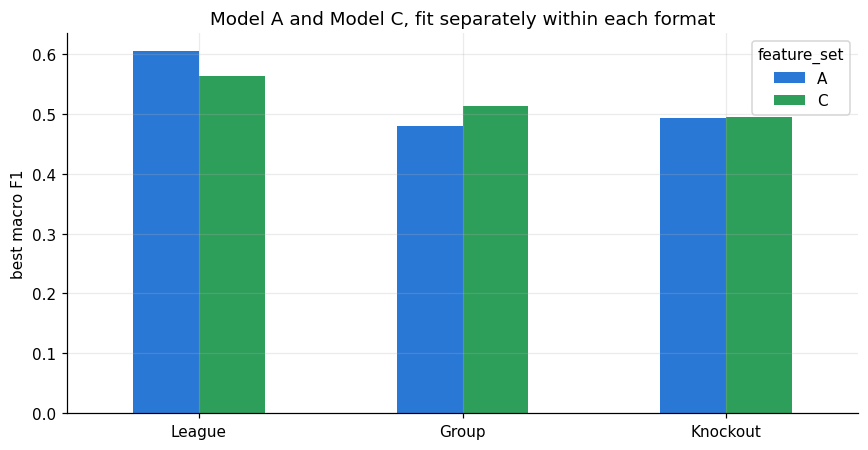

In [33]:
smc_path = RESULTS / "format_model_comparison.csv"
smc = pd.read_csv(smc_path) if smc_path.exists() and smc_path.stat().st_size > 0 else pd.DataFrame()
if smc.empty:
    smc = FC.stage_model_comparison(combined)
    smc.to_csv(smc_path, index=False)

if smc.empty:
    print("not enough matches in one or more stages for a grouped CV comparison yet")
    best_by_stage = pd.DataFrame()
else:
    best_by_stage = (smc.groupby(["stage","feature_set"]).macro_f1_mean.max()
                     .unstack().reindex(["League","Group","Knockout"]))
    print("best macro F1 per stage, Model A vs Model C (separate fit per stage)\n")
    print(best_by_stage.round(4).to_string())

    fig, ax = plt.subplots(figsize=(8, 4.2))
    best_by_stage.plot(kind="bar", ax=ax, color=[BLUE, GREEN])
    ax.set_ylabel("best macro F1"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.set_title("Model A and Model C, fit separately within each format")
    plt.tight_layout(); plt.show()

In [34]:
print("13.2 -----------------------------------------------------------------")
if best_by_stage.empty:
    print("skipped -- insufficient matches for a per-stage CV comparison.")
elif {"League","Knockout"}.issubset(best_by_stage.index):
    a_drop = best_by_stage.loc["League","A"] - best_by_stage.loc["Knockout","A"]
    c_drop = best_by_stage.loc["League","C"] - best_by_stage.loc["Knockout","C"]
    print(f"Model A: league {best_by_stage.loc['League','A']:.4f} -> knockout "
          f"{best_by_stage.loc['Knockout','A']:.4f}  (drop {a_drop:+.4f})")
    print(f"Model C: league {best_by_stage.loc['League','C']:.4f} -> knockout "
          f"{best_by_stage.loc['Knockout','C']:.4f}  (drop {c_drop:+.4f})")
    print()
    if a_drop > 0.03 and c_drop < a_drop - 0.02:
        print("FINDING: the scoreline predicts knockout outcomes noticeably worse than league")
        print("outcomes, AND performance indicators close part of that gap -- exactly the")
        print("shape of result the project's title is looking for: more room for 'beyond the")
        print("scoreline' signal exists precisely where the scoreline itself is weakest.")
    elif a_drop > 0.03:
        print("FINDING: the scoreline predicts knockout outcomes noticeably worse than league")
        print("outcomes, but performance indicators do not close the gap by a comparable amount.")
    else:
        print("FINDING: no material difference in scoreline predictiveness between league and")
        print("knockout football on this sample.")
else:
    print("insufficient knockout matches with a completed CV to compare directly.")

if "Group" in best_by_stage.index and "Knockout" in best_by_stage.index:
    print()
    print("Same-tournament control (Group vs Knockout, format isolated from level):")
    print(f"  Model A: group {best_by_stage.loc['Group','A']:.4f} -> knockout "
          f"{best_by_stage.loc['Knockout','A']:.4f}")
    print(f"  Model C: group {best_by_stage.loc['Group','C']:.4f} -> knockout "
          f"{best_by_stage.loc['Knockout','C']:.4f}")

13.2 -----------------------------------------------------------------
Model A: league 0.6043 -> knockout 0.4937  (drop +0.1106)
Model C: league 0.5626 -> knockout 0.4946  (drop +0.0680)

FINDING: the scoreline predicts knockout outcomes noticeably worse than league
outcomes, AND performance indicators close part of that gap -- exactly the
shape of result the project's title is looking for: more room for 'beyond the
scoreline' signal exists precisely where the scoreline itself is weakest.

Same-tournament control (Group vs Knockout, format isolated from level):
  Model A: group 0.4789 -> knockout 0.4937
  Model C: group 0.5137 -> knockout 0.4946


### 13.3 Honest limits of this section

* Knockout and group samples are in the hundreds, not thousands — CIs on these
  numbers are wide, and this section should be read as a lead for further work,
  not a headline result on the level of H1–H5.
* Home advantage is a different thing in a one-off international knockout tie
  (often a neutral or semi-neutral venue) than in a full league season —
  another way format and context are entangled here beyond stage alone.
* The league-vs-knockout comparison mixes club and international football;
  only the group-vs-knockout comparison (§13.2, second block) genuinely holds
  format constant.
